# The Qwen3-30B-A3B / MI355X linear_op profiling story — source material for the HTML write-up

Compiled 2026-09-22 from the numbered documents in `profiling_knowledge/qwen3_30b_a3b_mi355x_profiling/`, the run records
under `data/profiling/compute/mi355x/qwen3-a3b-30b-moe/runs/*/RUN.md`, the implement/debug-loop records in
`amd-playground/.claude/debug-reports/`, and the git history of branch `smatar/qwen3-30b-mi355-profiling`. Every chapter
below follows the same shape — **what we saw → the picture → the analysis → the decision → the fix → what changed** — so it
can be dropped into a page section by section. Figures are in `figures/` and are regenerated by `make_story_figures.py`
(see §"Reproducing the figures"). Every number cited carries its Slurm job id or document section so it can be checked.

Times are the Memphis cluster clock (UTC). Commit hashes are on `smatar/qwen3-30b-mi355-profiling`.

## 0. The one-paragraph version

We inherited MI355X profiling CSVs for Qwen3-30B-A3B that had been collected before this workstream (TORCH_SDPA attention,
linear ops up to 4,096 tokens, 20 timed repetitions, aggregates only). We re-collected with the production AITER attention
kernels, 50 timed repetitions per shape and **every run kept in execution order**, then plotted the linear-op data on a dense
3,327-token grid. Keeping the raw runs is what made everything that followed possible. Three anomalies surfaced in turn,
each traced to a root cause with a written brief, a pre-stated prediction and a confirming experiment: (1) a 150–290 ms
spike in exactly one run of one op in 32 rows — **a CPython full garbage collection** on the worker thread, fixed by
disabling GC around the timed loop; (2) a **V-shaped dip** and flat plateaus in `attn_post_proj`/`attn_rope` medians at
TP>1 — **not a GPU effect at all** but CUDA-event pairs measuring the host's launch span while the device idled, fixed by
timing every shape twice (legacy + GPU-bound pass), adding a per-row clock probe and agreeing a measurement contract;
along the way we found that `attn_rope` had been timing a numerically wrong torch fallback and replaced it with the fused
kernel; (3) after re-collecting with all fixes, two **run-position patterns** — a 2–8 % within-block drift caused by the
clock domains idling during the backlog spin, and a fixed-position 5.5 µs bump caused by the ROCm runtime's 1000-command
batch-flush barrier, the latter removed with a runtime flag and verified. The old canonical `linear_op.csv` overstated GEMM
costs by 1.3–2.9× and RoPE by 4–12× over large parts of the grid; the new collections are monotonic, instrument-accounted
and agree with kernel traces to a constant ≈3 µs per scope boundary.

## 1. Timeline

| when (UTC) | what happened | jobs | commit / document |
|---|---|---|---|
| before 2026-09-10 | Inherited MI355X data exists: TORCH_SDPA attention (block 16, 9.4k ctx, 5 reps), `linear_op` ≤4,096 tokens (20 reps), no per-run samples, no `head_dim` | — | `MI355X_FOUR_MODEL_PROFILING.md`; now `runs/legacy_pre-2026-09_torch-sdpa/` |
| 2026-09-10 → 09-14 | Plan loop for the re-collection: requirements, source map, five iterations + nine "slim" iterations with an external reviewer; decisions: AITER backend, `head_dim` required, **50 timed + 3 warm-up runs per shape with every run recorded in order**, block 1 ∪ block 16 canonical, grid as the profiler measures it | — | `00_requirements_and_source_map.md`, `01_plan.md`, `review/` |
| 2026-09-14 | Code: require `head_dim`; keep all 53 samples per scope (`time_stats.<op>.samples`, `warmup_count`) | — | `deef568` |
| 2026-09-15 07:xx–11:xx | Pilots fail on NFS root-squash, missing images, then an **aiter `mha_batch_prefill` memory fault** for head_dim 128 in `v0.5.11`; attention moved to `v0.5.17-rocm720`, linear_op stays on `v0.5.11` (needs vllm) | 21280–21305 | `02_run_record.md`, `0fcac5f` |
| 2026-09-15 11:42 | First real runs: linear_op on the 386-token default grid; attention 16k, blocks 16 and 1 | 21309, 21310, 21311 | `runs/2026-09-15_1142_*`, `b65842c` |
| 2026-09-15 13:08 | **Dense linear_op grid**: 3,327 token counts × TP {1,2,4,8} = 13,308 rows ("collecting data is cheap") → becomes the canonical `linear_op.csv` | 21313 | `runs/2026-09-15_1308_linear_op_dense3327/` |
| 2026-09-15 13:15–13:59 | Attention at 32k and 64k context | 21314–21317 | `runs/2026-09-15_1315_attention_{32k,64k}/` |
| 2026-09-15 13:59 | Spike seen in the dense data; 26-token band re-run three times → **not reproduced** | 21323–21325 | `03_linear_op_spike_investigation.md`, `runs/2026-09-15_1359_linear_op_spike_repro/` |
| 2026-09-15 12:26 | Dataset README (schema, new vs old, recipes) | — | `da1ae75` |
| 2026-09-16 06:29 | Full dense grid re-run on another node → **spike reproduces exactly** (same tokens, same run index, every TP) → systematic, position-keyed | 21334 | `runs/2026-09-16_0629_linear_op_dense3327_rerun/`, `7f4dfa5` |
| 2026-09-16 07:xx | Specialist brief for the spike; twelve instrumented experiments E1–E8 → **root cause: CPython gen-2 GC** | 21342–21353 | `04_…brief.md`, `05_linear_op_spike_root_cause.md`, `c7d49c3` (08:44) |
| 2026-09-16 08:53 | GC fix (`gc.disable()`/`gc.enable()` around the timed loop) verified on the full grid against five pre-stated acceptance criteria | 21361, 21362 | `data/profiling_gcfix/RUN.md` |
| 2026-09-16 | Dip brief written (hipBLASLt tile hypothesis); dip root cause: backlog knob X1 removes dip and plateaus; rocprofv3 traces X2/X2d → **host-launch-bound measurement** | 21356, 21357, traces 08:38 | `06_…brief.md`, `07_…root_cause.md` |
| 2026-09-16 12:31 | **Pre-registration** of the validation: predictions for both hypotheses, 7 falsification conditions, written before any run | — | `08_measurement_validation_preregistration.md` |
| 2026-09-17 06:xx–08:46 | Validation runs (single-process traces, 8-worker pipeline, with/without knob); H0 stands, F6 fires; **two-column timing** implemented through an implement-loop and validated on the 8-token grid | 21376–21378, 21385–21391 | `09_…results.md`, `debug_linear_op_host_bound_timing_2026-09-16.md`, `implement_…two_column_timing_2026-09-17.md`, `d4469be`, `74eee7c` |
| 2026-09-17 09:41–10:16 | Clock lock at 1900 MHz (shows the TP4/TP8 residual is clock); loop-length test (25/50/100 forwards → F6 is queue backpressure); **per-row shader-clock probe** and host-enqueue columns; warm-up does not warm the clock | 21395–21400 | `09_` §3a–3b, `runs/2026-09-17_1016_…_probe/`, `9dac93b` |
| 2026-09-17 10:55 | **Measurement contract agreed**: option (a) kernel-only device time at a stated clock + separate overhead term | — | `10_measurement_contract.md`, `ec63f31` |
| 2026-09-17 11:40–12:50 | Recollection plan (plan-loop, 3 iterations); TASK-1: **RoPE on the fused kernel** — the forced torch fallback was numerically wrong; vLLM's own object dispatches to a 17-kernel torch path on ROCm; Frontier's class + `vllm._custom_ops.rotary_embedding` is the fused kernel SGLang also launches | 21402–21412 | `11_attn_rope_task.md`, `linear-op-recollection-contract-a.md`, `implement_linear_op_recollection_2026-09-17.md`, `runs/2026-09-17_1250_linear_op_rope_fix_validation_grid/` |
| 2026-09-22 06:47 / 08:42 | **Dense grid re-collected with every fix**: 25 forwards per shape (3.5 min) and 200 forwards as 8 spun blocks of 25 (19 min); medians agree 1.000 | 21483, 21486 | cluster `data/profiling_dense_fixed/`, `data/profiling_dense200/`; notebooks `viz/linear_ops_dense_fixed_*`, `viz/linear_ops_old_vs_fixed_*` (`2293764`, `964d113`) |
| 2026-09-22 09:34–11:47 | Plain-language summary of the dip investigation; commit of rope fix + spun blocks | — | `12_dip_investigation_summary.md`, `4b8fce3` |
| 2026-09-22 13:xx–15:43 | Run-position anomalies in the new data: within-block drift (spin → clock idle) and run-20 spike (ROCclr 1000-command batch-flush barrier); barrier fix validated and a full dense grid re-collected with it | 21491–21495, 21499, 21500 | `13_run_position_anomalies_root_cause.md`, `run_position/README_dense_fixed_batchflush.md`, cluster `data/profiling_dense_fixed_batchflush/` |

## 2. Chapter 0 — what we started from

**Situation.** The repository already held MI355X compute profiles for `qwen3-a3b-30b-moe`, collected in an earlier
workstream (`MI355X_FOUR_MODEL_PROFILING.md`). For the linear ops that file covered token counts up to 4,096 with 20 timed
repetitions and stored only min/max/mean/median/std. Attention used the portable TORCH_SDPA kernel, not the production
AITER kernels, and had no `head_dim` column. The simulator's per-operator regressors train on `time_stats.<op>.median`.

**Decision (plan loop, 2026-09-10 → 09-14).** Re-collect on the AITER backend with `head_dim` recorded, raise the timed
repetitions from 5/20 to **50** (3 warm-ups), and keep **every timed run in execution order** as a JSON list per scope so that
warm-up effects and noise outliers can be told apart afterwards. MoE deferred. Block 1 and block 16 both collected. The plan
went through five reviewer iterations (each finding verified against the code; none rejected) and a divergence report
before approval (`review/divergence_report.md`).

**Figure** `f00_baseline_inherited_vs_50rep.png` — inherited `attn_pre_proj` medians vs our first 50-repetition run on the
default 386-token grid. On the shared shapes the two agree; the new run extends to 16,384 tokens.

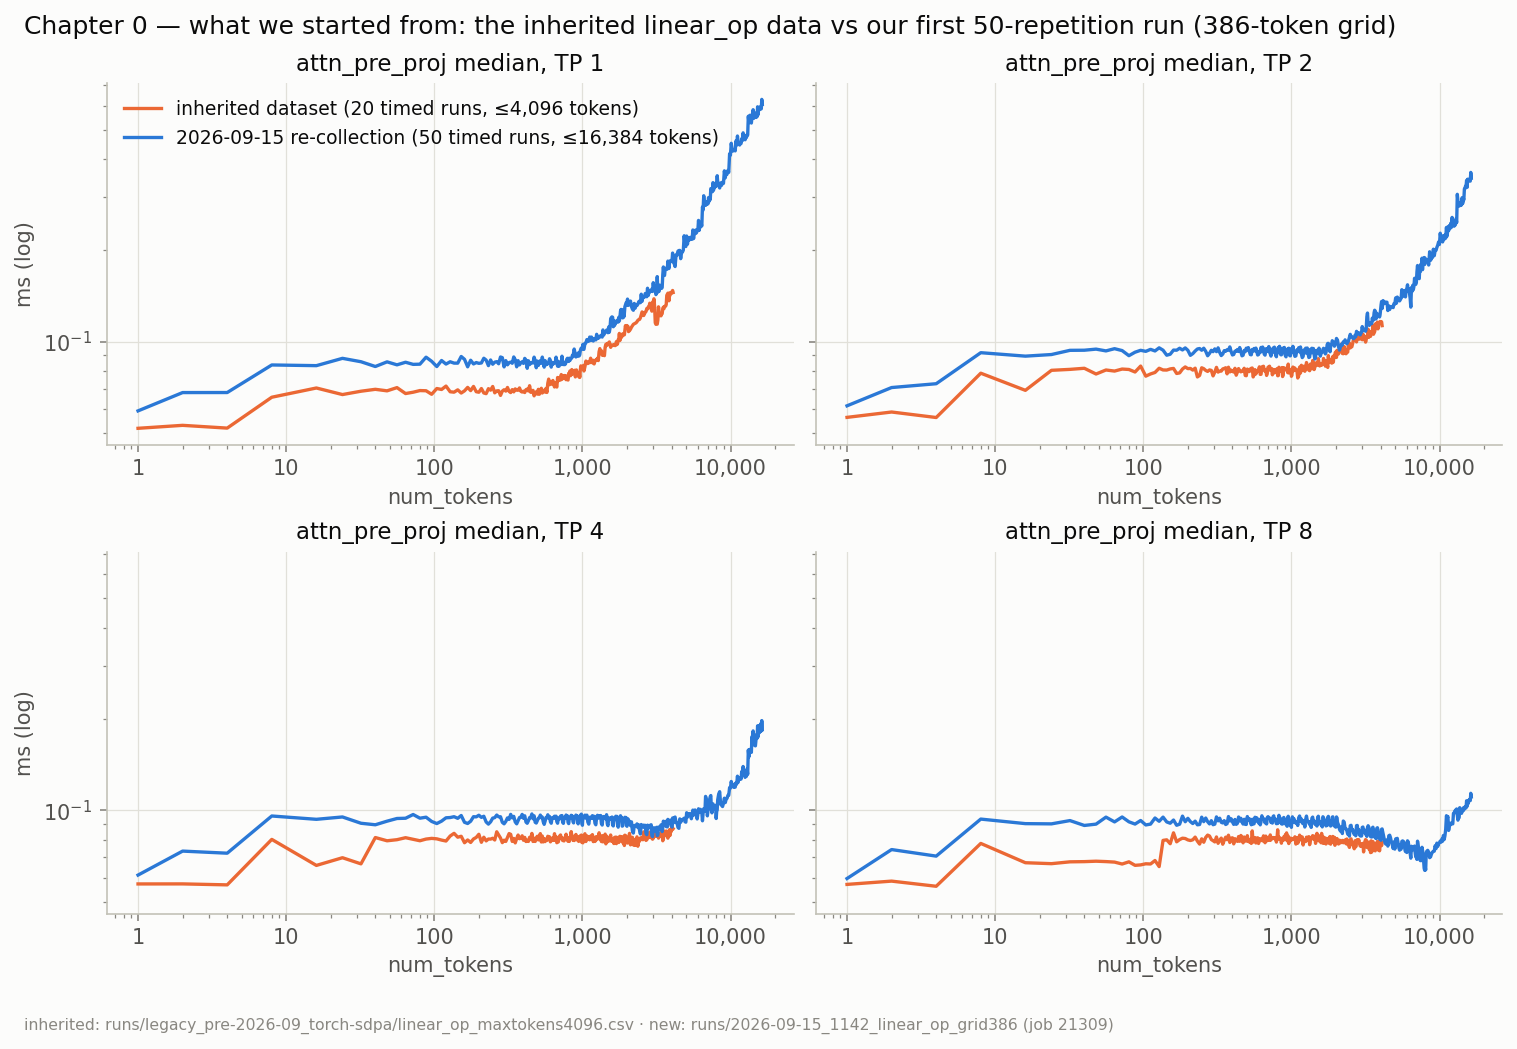

<sub>`f00_baseline_inherited_vs_50rep.png`</sub>

**What the environment taught us on day one** (`02_run_record.md`): `/opt/shared` is root-squashed so every output directory
must be pre-created and world-writable; Docker images are per node; the pinned `v0.5.11` image's aiter prefill kernel faults
for head_dim 128 with paged KV (both block sizes), so attention runs on `v0.5.17-rocm720` while linear_op stays on `v0.5.11`
(it imports vllm, which `v0.5.17` dropped). Eleven pilot/repro jobs (21280–21305) before the first clean run.

## 3. Chapter 1 — the run-11 spike

**What we saw (2026-09-15, job 21313).** Plotting the dense grid's mean and max next to the median showed a needle: in
exactly 32 rows — `num_tokens` 1968…1975 × TP {1,2,4,8} — one timed run of `attn_pre_proj` took **150–270 ms** where the other
49 took ~0.13 ms. It was always **timed run 11** (absolute sample 14, i.e. the 15th forward including 3 warm-ups). Medians were
untouched; means rose to 3–5 ms, max to 150–270 ms. No other op showed it. The same shapes on the 386-token grid the same
morning were clean.

- `f01_spike_envelope_dense_original.png` — min–max envelope, mean and median per TP; the spike rows marked.
- `f02_spike_one_row_samples.png` — the 53 recorded samples of one affected row; run 11 at ≈150 ms.
- `f04_run_position_fingerprint_original.png` — median over all rows of sample_k ÷ row median: fixed run positions (11, 16–17,
  33, 49) sit systematically above 1.0 in *every* row (this figure computes it per TP; `05_` §3.6 quotes the pooled
  values 1.31 at run 11 and 1.05 at run 33).

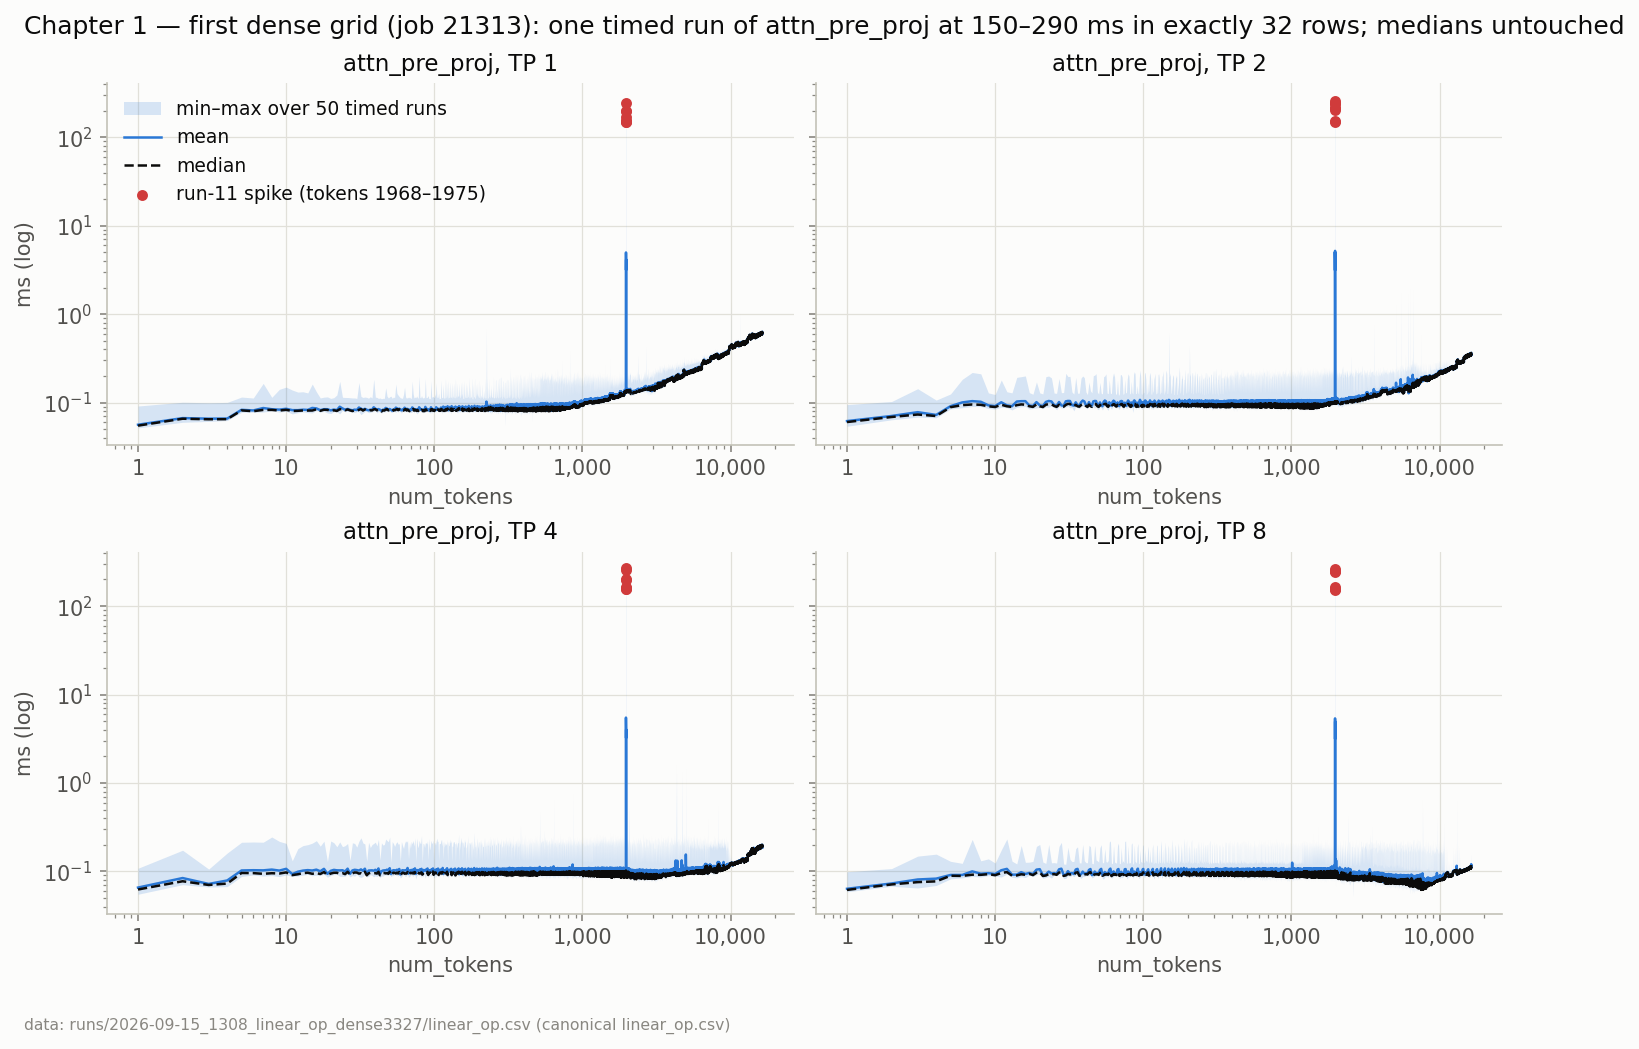

<sub>`f01_spike_envelope_dense_original.png`</sub>

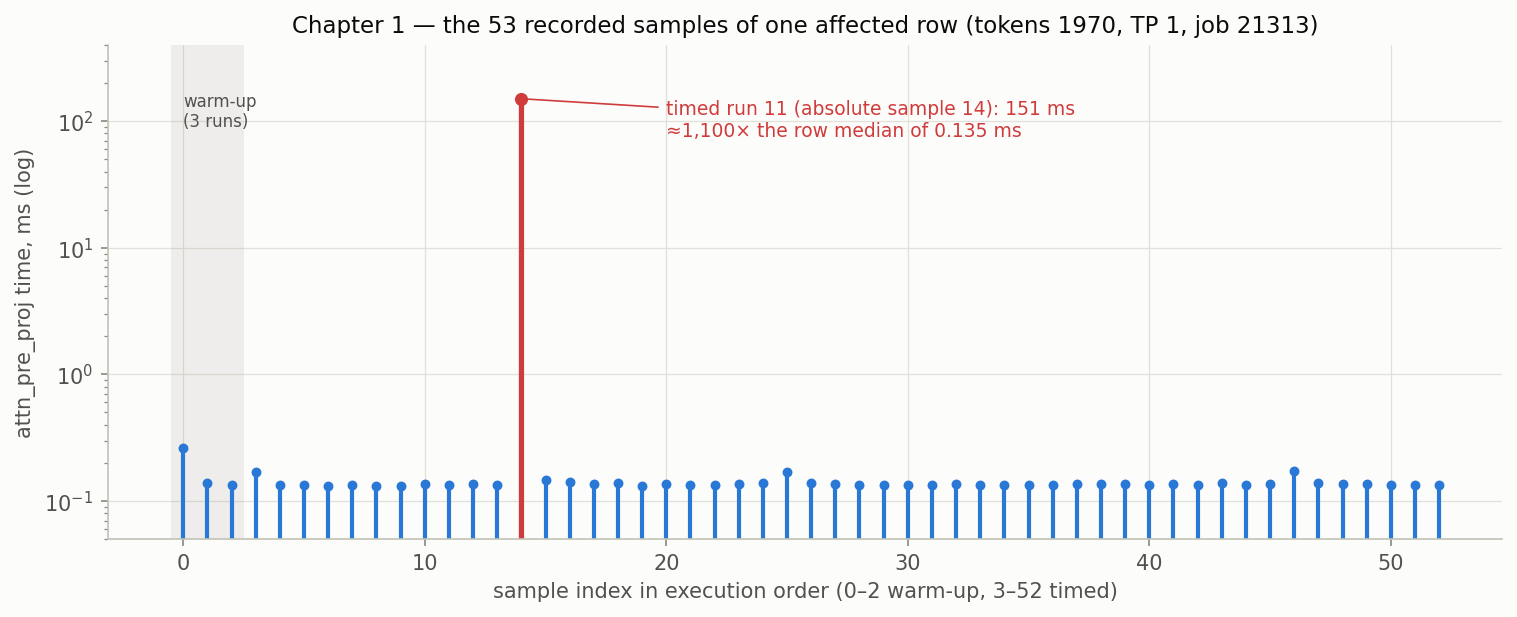

<sub>`f02_spike_one_row_samples.png`</sub>

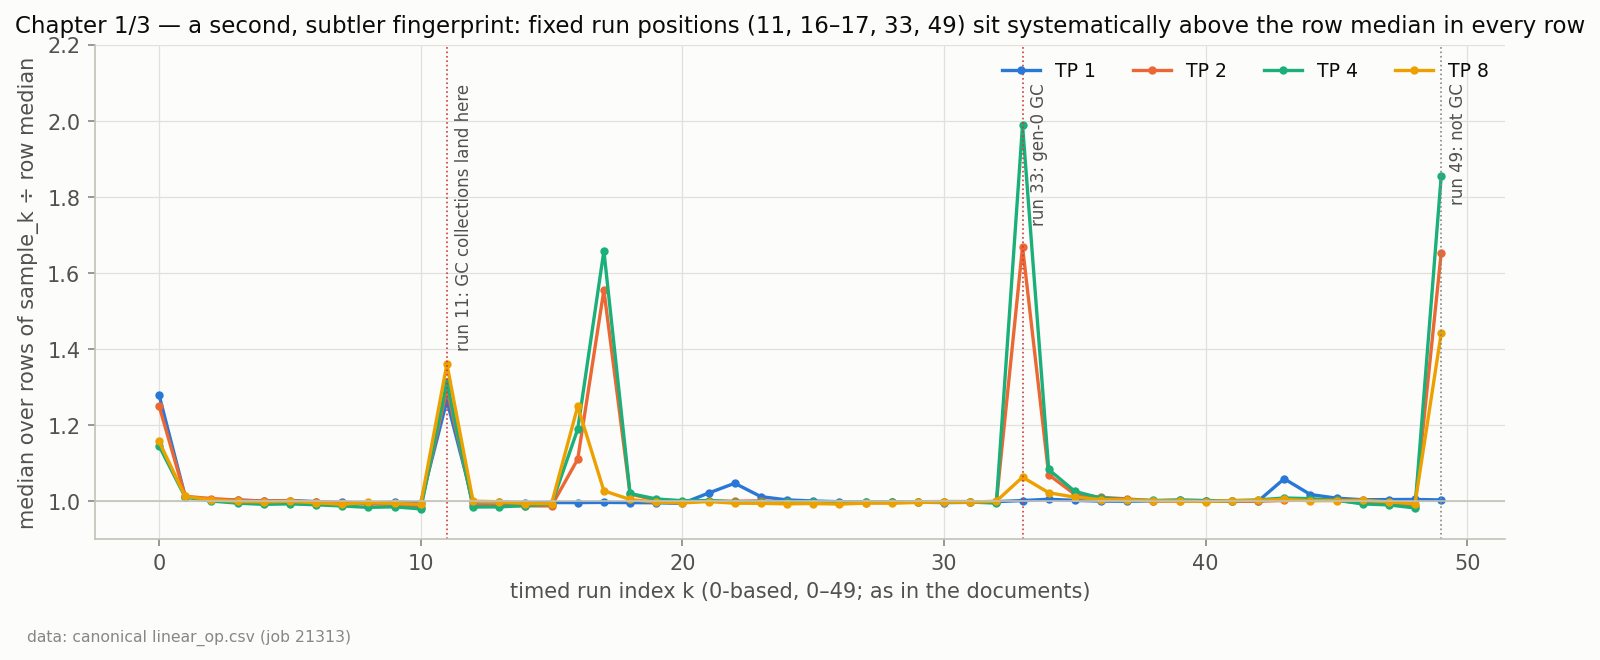

<sub>`f04_run_position_fingerprint_original.png`</sub>

**Analysis, first pass (`03_`).** Two candidate explanations were set against each other: (a) a shape-triggered kernel/autotune
event (deterministic, would recur), or (b) a one-off stall (would not). Reading `main.py` explained why 8 consecutive tokens
and the same run index: tasks are ordered TP-outer, tokens **descending**, dispatched round-robin to 8 GPU workers, and every
TP pass starts fresh worker processes — so the eight rows are one task per worker at the same per-worker position, in lockstep.

**Decision.** Re-run the 26-token band three times (8 workers ×2, 1 worker ×1; jobs 21323–21325). **Result: not reproduced.**
The first write-up therefore leaned to "one-off stall" while noting it could not explain why all four TP passes hit the same
band — and proposed the discriminating experiment: re-run the *full* sweep from 16,384 down.

## 4. Chapter 2 — the spike reproduces exactly

**What we saw (2026-09-16 06:29, job 21334).** The full dense grid, byte-for-byte the same command, on a different node 17
hours later: the same 32 rows, `attn_pre_proj`, timed run 11, 150–263 ms. Nothing else in the file above 20× its median
(except the usual `emb` warm-up outlier). Medians agree with the first run (ratio p50 0.998).

- `f03_spike_band_first_vs_rerun.png` — run-11 sample ÷ row median across tokens 1940–2010, both runs: the same eight tokens light up.

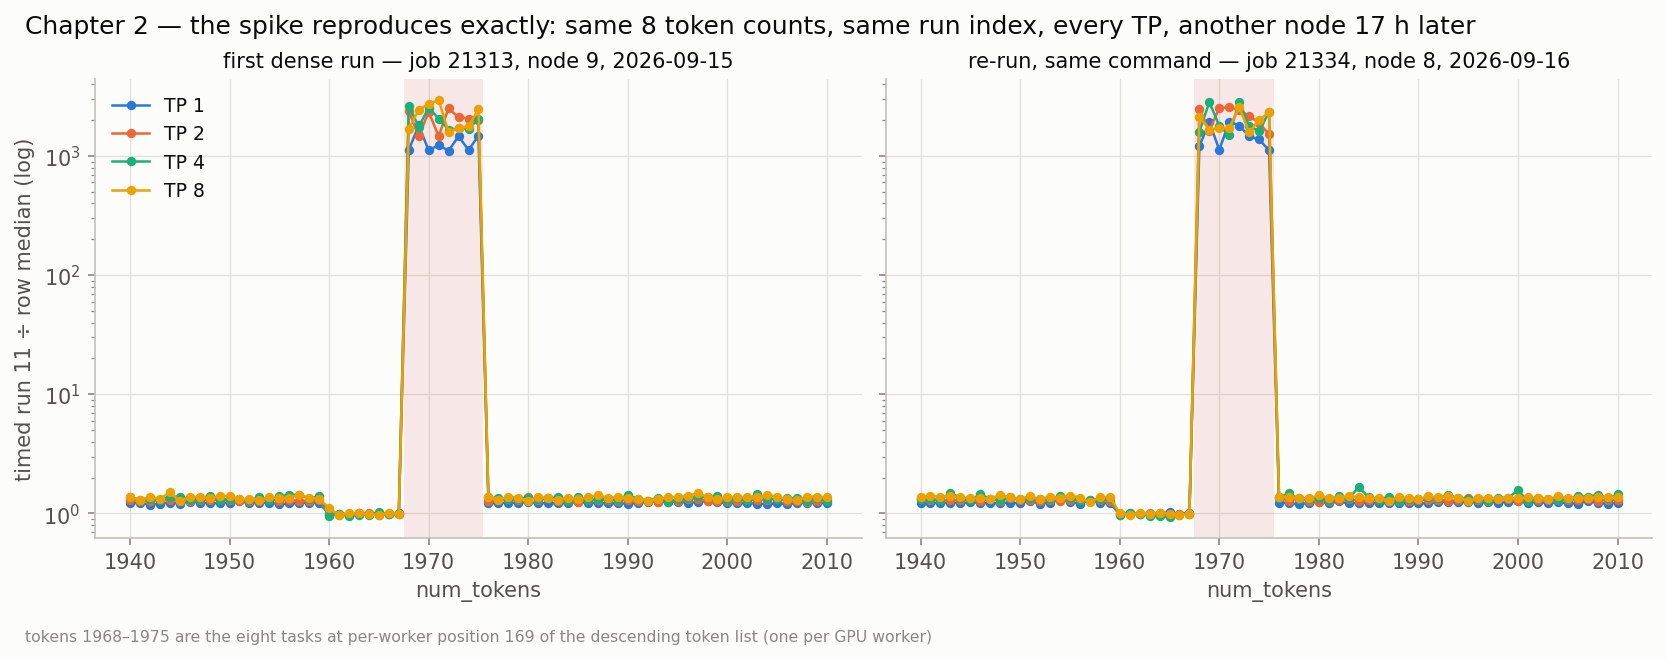

<sub>`f03_spike_band_first_vs_rerun.png`</sub>

**Analysis.** Environmental stall ruled out. The 26-token repro had missed it only because it started at token 1985 instead
of 16,384: the trigger is **history inside the worker process**, not the shape. Tokens 1968–1975 are the eight tasks at
per-worker position 169 of the descending list. Candidates named: the PyTorch caching allocator, a lazily-loaded
hipBLASLt kernel, 8-process contention. A self-contained specialist brief (`04_`) collected facts, environment, code paths and
proposed experiments (shift the token list; fewer workers; allocator logging).

**Decision.** Keep the canonical file (medians are unaffected; drop run 11 of the 32 rows for sample-level work) and run the
root-cause investigation with instrumentation rather than guess.

## 5. Chapter 3 — root cause: a CPython full garbage collection

**How it was proven (2026-09-16, jobs 21342–21353, `05_`).** An opt-in diagnostic module (`spike_diag.py`, inert unless
`FRONTIER_SPIKE_DIAG` is set) records every GC collection via `gc.callbacks`, the host wall time of each of the 53
forwards, and all per-op sample lists per task, using only non-GC-tracked appends inside the timed loop. Twelve jobs:

| experiment | change | outcome |
|---|---|---|
| E6 | module present, recording off (baseline) | original band 1968–1975, run 11, 144–259 ms — third reproduction |
| E1b / E7 | diagnostics on | band moves to tokens 2944–3000 (task 145: the hooks add allocations); one gen-2 collection per worker, **inside forward 14**, duration = event gap ±1 ms |
| E3b | token list 1…2048 | band at tokens 881–888 = task 145 of *that* list — predicted before the run |
| E4b | 2 workers instead of 8 | same durations (146–258 ms) → contention ruled out |
| E1 / E3 | `gc.collect()` at worker init | no gen-2 collection in the whole pass, no spike |
| E2 / E2b | `gc.freeze()` at init | spike still at run 11 but 52–124 ms (frozen objects not traversed) |
| **E5** | **`gc.disable()` at init, no recording** | **band gone; largest sample in 13,308 rows = 2.1 ms** |
| E8 | 200 repetitions per task | nine gen-2 collections per worker at runs 11/55/77/99/165/187 as predicted; only the run-11 ones fall inside a timed scope, the rest stall the GPU ≈200 ms *invisibly* |

- `f05_gc_gen2_duration_vs_spike.png` — gen-2 collection duration vs the `attn_pre_proj` sample of the same forward
  (E1b): all 32 points on the identity line; all collections start in forward 14.
- `f06_gc_counter_model.png` — why forward 14: the gen-0 net counter restarts near 0 every task (the previous model is freed),
  grows ≈255 during build and ≈32 per forward, crossing the threshold 700 at forward 14 and again at 36; the full collection
  fires at the first such point after CPython's `long_lived_pending ≥ long_lived_total/4` rule is met — once per 416-task pass.

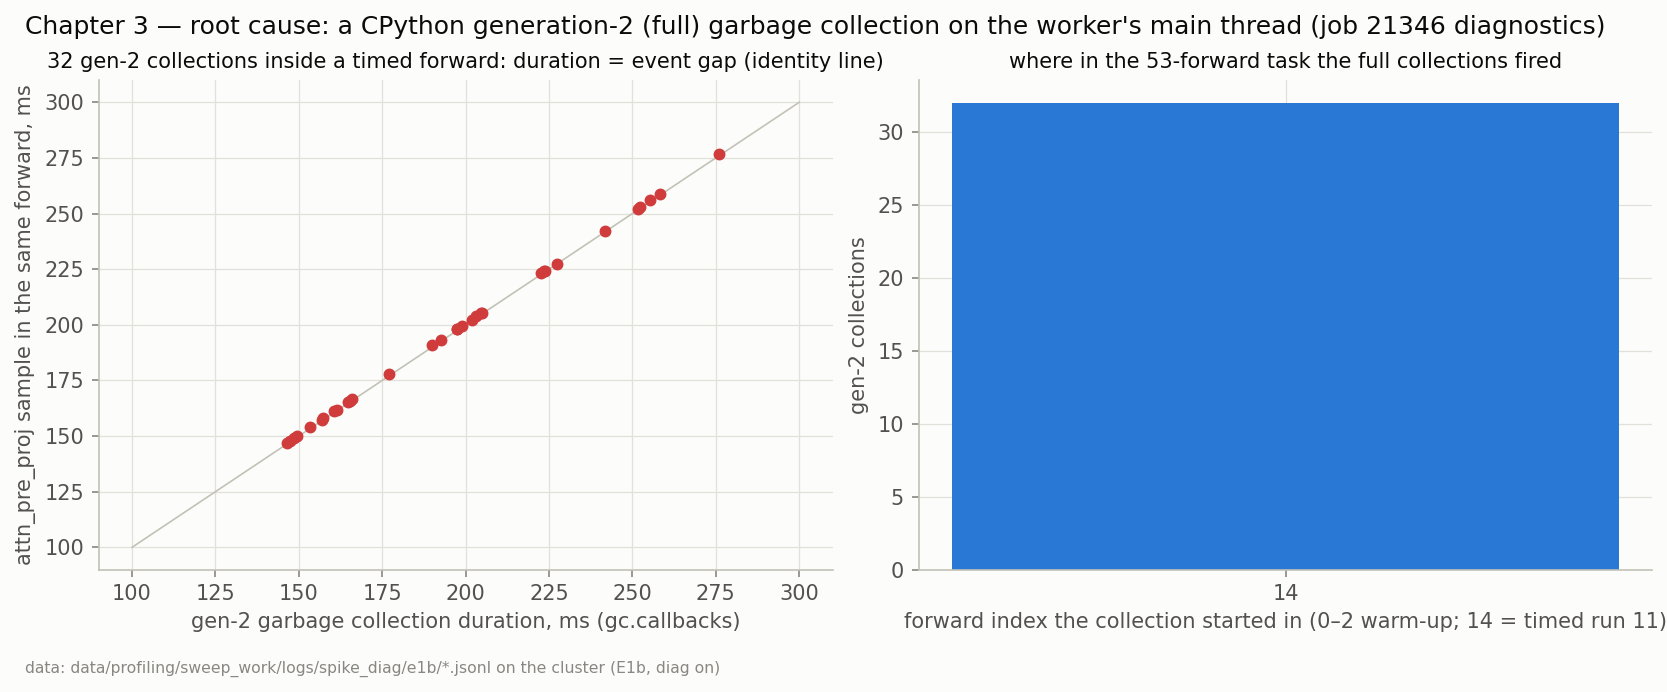

<sub>`f05_gc_gen2_duration_vs_spike.png`</sub>

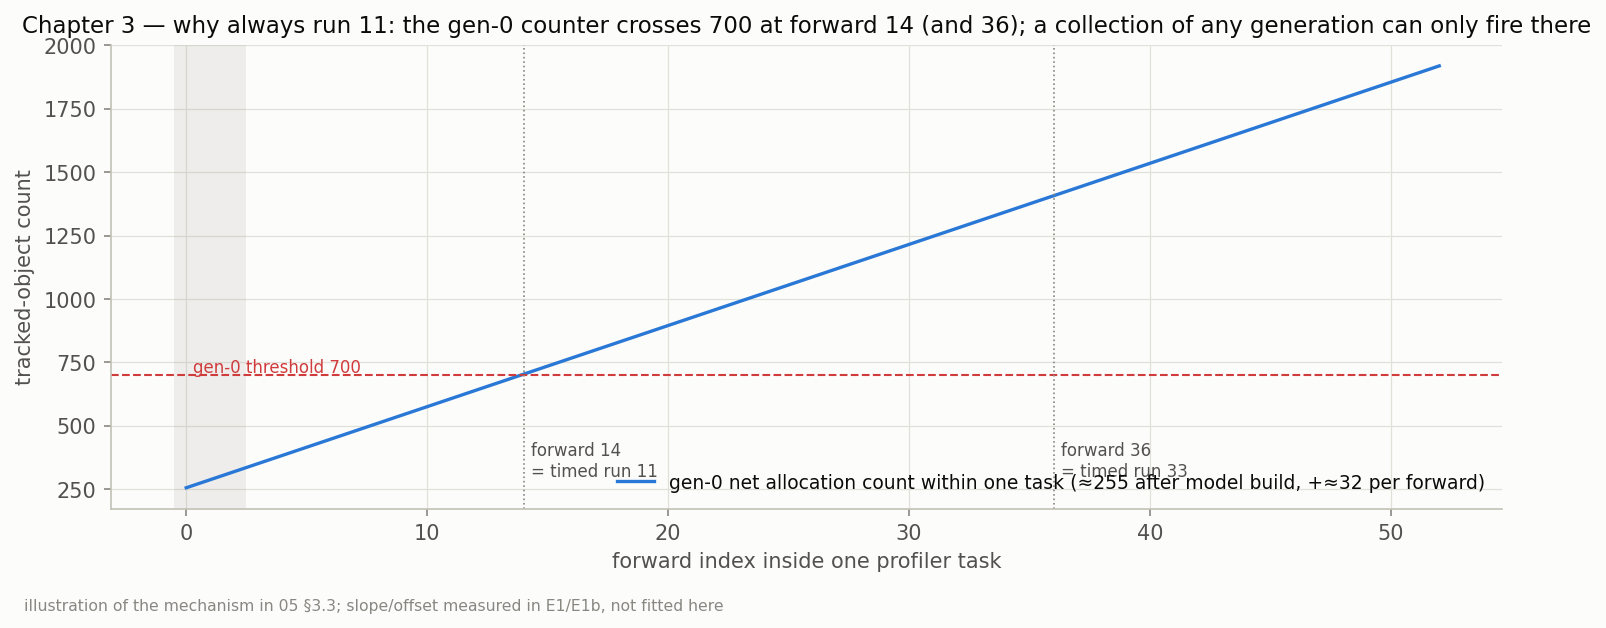

<sub>`f06_gc_counter_model.png`</sub>

**Ruled out** (with evidence): caching allocator (counters flat), hipBLASLt lazy work and HIP housekeeping (the gap is fully
accounted for by the collection), contention, shape, environment. **Side findings:** the cheap gen-0/gen-1 collections leave
the run-11/run-33 fingerprint in every row; a separate sporadic ≤2 ms host-jitter class exists at random positions.

**Decision / fix plan (05 §7).** `gc.disable()` immediately before the warm-up loop and `gc.enable()` in a `finally` after the
final synchronize in `LinearOpWrapper.profile`; no `gc.collect()` in the per-task path. Five acceptance criteria written before
the verification run. Root cause committed as `c7d49c3`.

## 6. Chapter 4 — the GC fix, verified

**Run (2026-09-16 08:53, jobs 21361 + 21362 with diagnostics; `data/profiling_gcfix/RUN.md`).** Same command as the re-run,
with the hunk (commit `74eee7c`):

```python
gc_was_enabled = gc.isenabled()
gc.disable()
try:
    for _ in range(WARMUP_STEPS): self.model(input_ids, positions)
    torch.cuda.synchronize(); self.timer_stats_store.mark_warmup_end()
    for _ in range(ACTIVE_STEPS): self.model(input_ids, positions)
    torch.cuda.synchronize()
finally:
    if gc_was_enabled: gc.enable()
```

| # | criterion | result |
|---|---|---|
| 1 | no `attn_pre_proj` sample > 5 ms | max 2.09 ms (was 32 rows at 144–290 ms) — PASS |
| 2 | only the sporadic ≤2.5 ms class above 20× median | 19 rows, max 2.06 ms, random positions — PASS |
| 3 | per-op median ratio vs re-run: p50 within 0.98–1.02, p5–p95 within 0.90–1.10 | p50 0.993–1.000 all ops; p5–p95 PASS for the GEMMs, **FAIL** for `emb`/norms/`attn_rope` — but the same band is violated between the two *unmodified* runs: the criterion was tighter than the noise floor of 13–18 µs kernels |
| 4 | fingerprint gone: sample_11/median < 1.10 | 0.997 (was 1.31) — PASS |
| 5 | every gen-2 collection outside every forward window | 32/32 landed after the last forward of a task — PASS |

- `f07_gcfix_max_over_median_before_after.png` — per-row max ÷ median before/after.
- `f08_fingerprint_before_after_gcfix.png` — the run-11 fingerprint disappears; bumps at runs 0, 16, 49 remain (not GC).

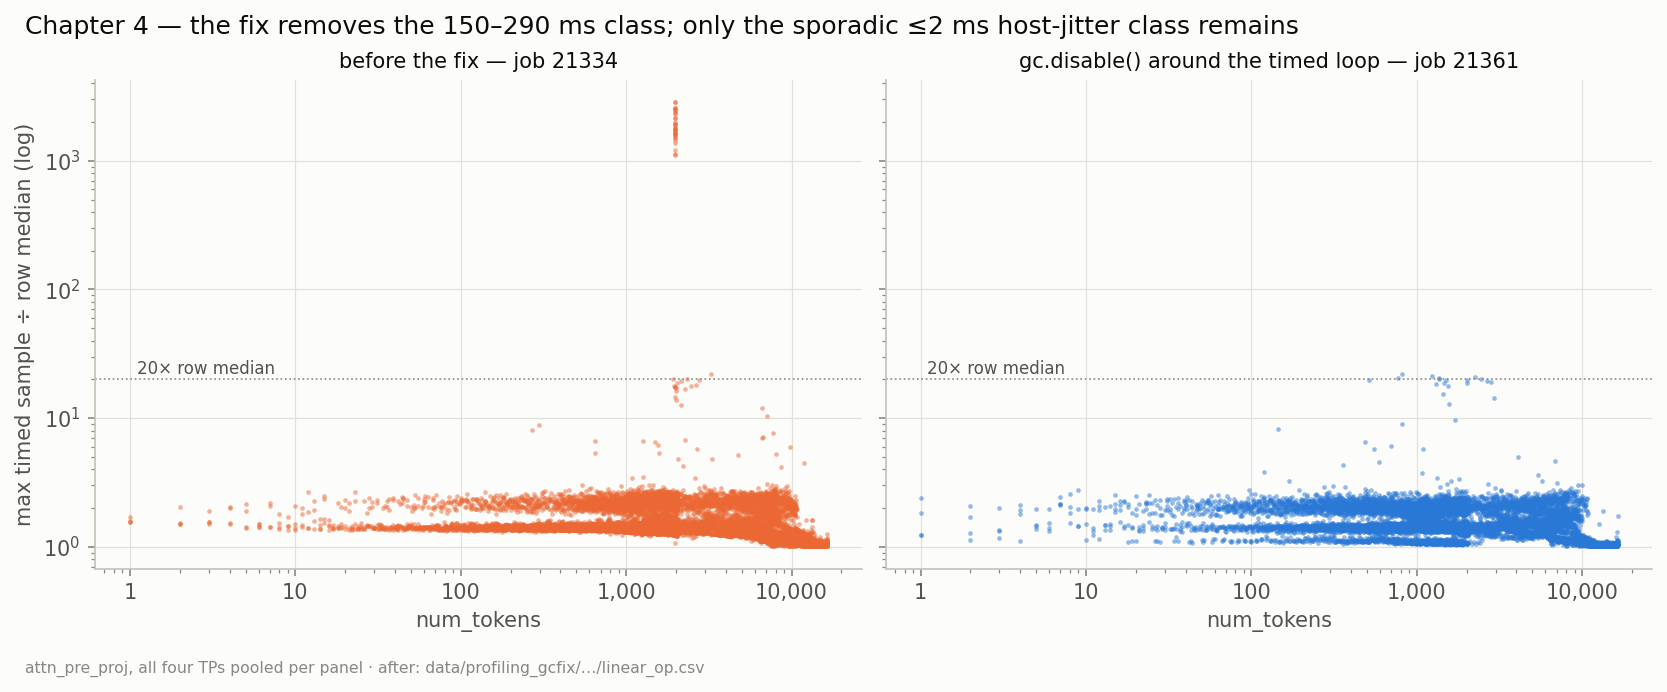

<sub>`f07_gcfix_max_over_median_before_after.png`</sub>

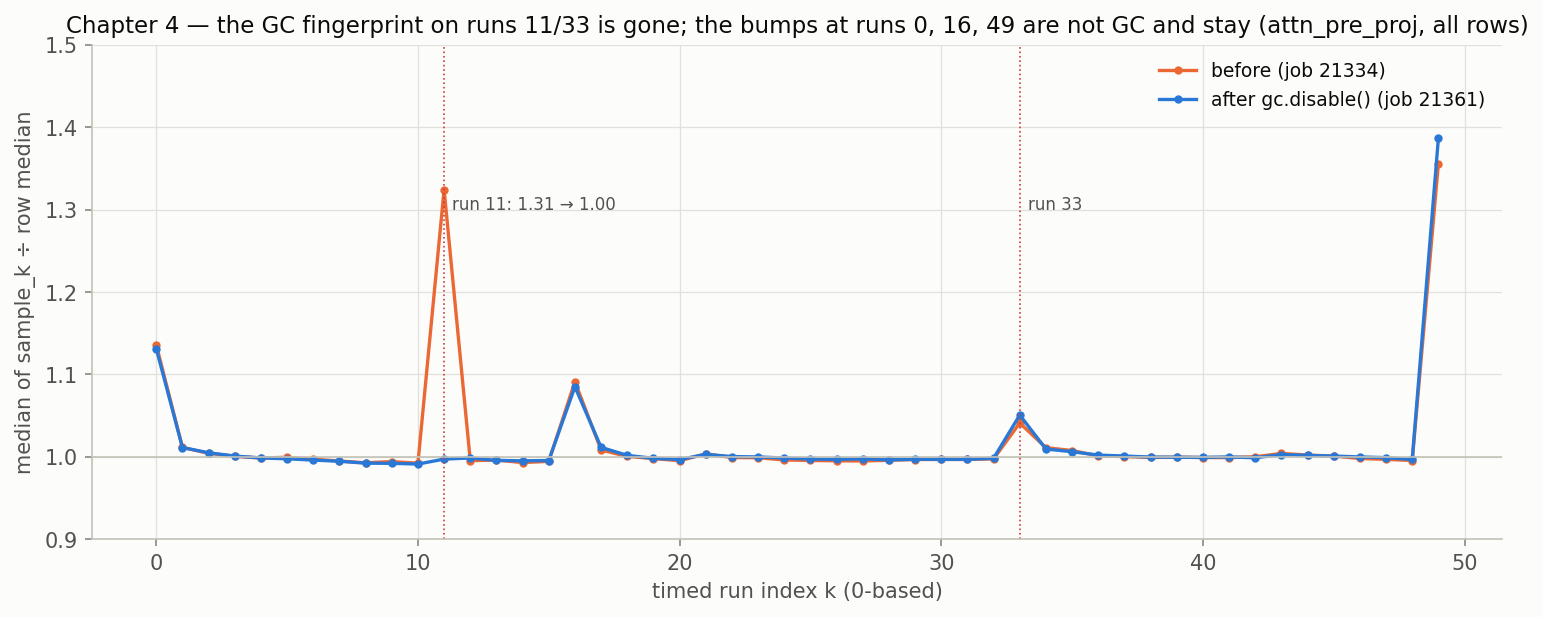

<sub>`f08_fingerprint_before_after_gcfix.png`</sub>

**Decision.** Fix kept (it changed no median); criterion 3 recorded as mis-specified for the elementwise ops. The canonical
`linear_op.csv` was *not* replaced at this point because the next chapter was already open.

## 7. Chapter 5 — the V-shaped dip

**What we saw (from the same dense data).** In the run-group notebook (`viz/linear_ops_run_groups_and_stats.ipynb`), the
medians of `attn_post_proj` and `attn_rope` at TP 2/4/8 **fell** by 17–37 % somewhere in 4,000–6,000 tokens and then climbed
back — a V — while `attn_pre_proj` in the same forwards showed no V. Below the dip the curves were flat plateaus over
thousands of tokens, which makes no sense for a GEMM whose M grows 100×. The independent re-run reproduced the trough within
~100 tokens and 2 percentage points.

- `f09_dip_medians_original.png` — the three ops, four TPs, 1k–16k tokens, dip band shaded.
- `f10_dip_row_samples_bimodal.png` — the fingerprint the brief missed: inside the dip the 50 samples of a row are bimodal
  and drift downward within the task; past the dip they are tight. The traced kernel is the lower mode.

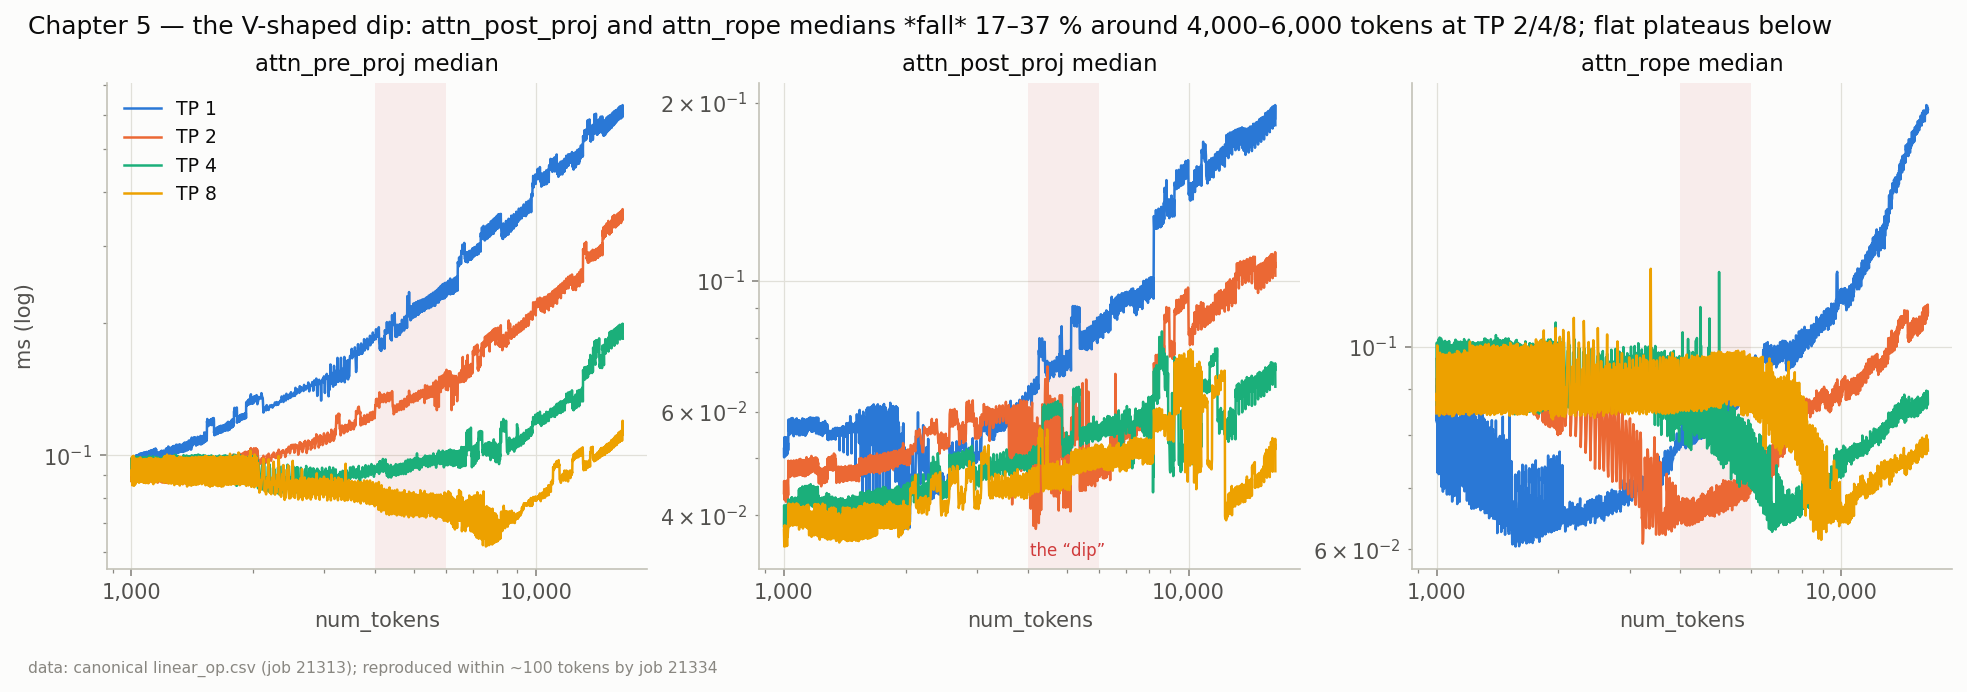

<sub>`f09_dip_medians_original.png`</sub>

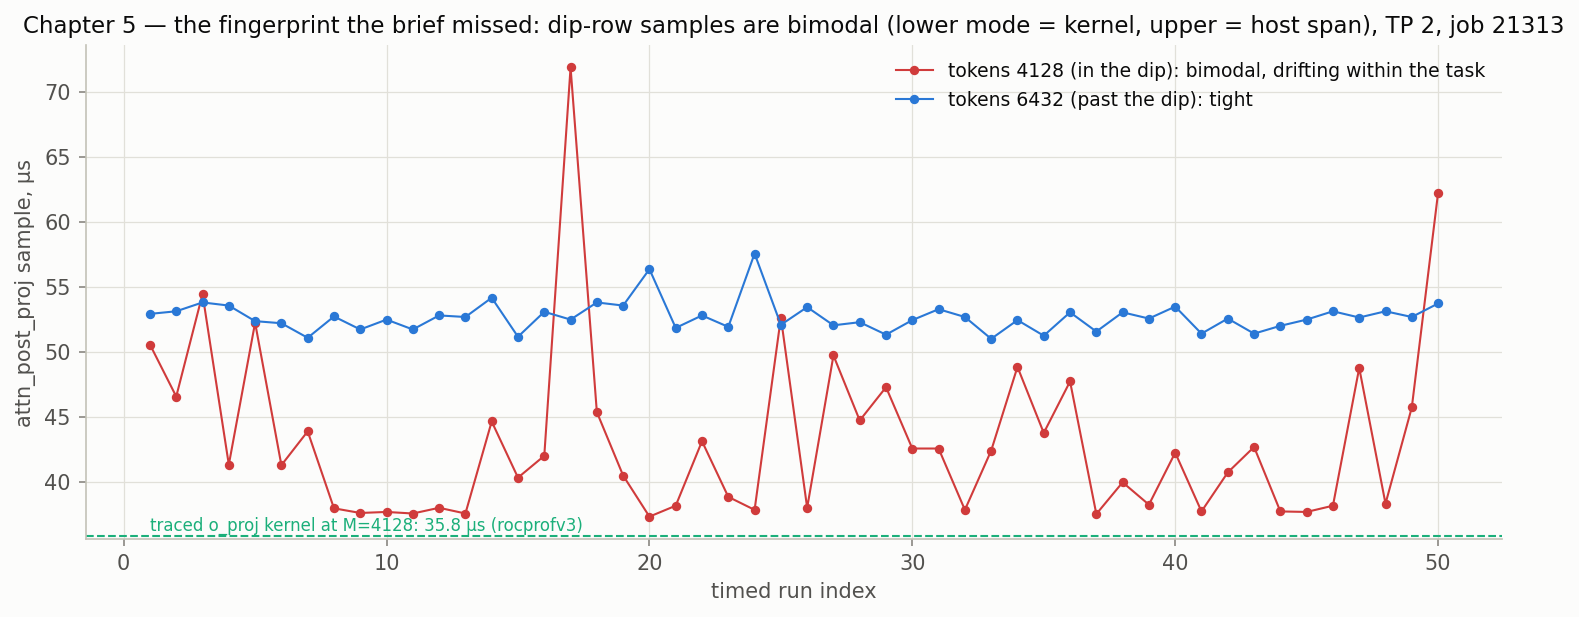

<sub>`f10_dip_row_samples_bimodal.png`</sub>

**Analysis, first pass (`06_`, 2026-09-16).** Code-verified facts: `attn_post_proj` is pure GEMM (`reduce_results=False`, no
collective in scope), and its contraction dimension K = 4096/TP changes with TP while `attn_pre_proj`'s K is fixed at 2048 —
tracking exactly which op dips. Candidates ranked: (1) a hipBLASLt kernel-selection boundary keyed to K, (2) a RoPE-kernel
occupancy effect, (3) wall-clock/scheduling. Both leading candidates assumed the CSV number is GPU time.

**The alternative reading.** A CUDA-event pair records when the device *reaches* the start event to when it reaches the end
event. If the device is idle when the start event is enqueued, the pair measures the **host's launch span** for that scope,
not the kernel. Looking at the plateaus more closely raised this.

## 8. Chapter 6 — root cause: the profiler was measuring the host

**Experiments (2026-09-16, `07_`).**

- **X1 (job 21356):** one opt-in knob, `FRONTIER_GPU_BACKLOG_MS=100` — a calibrated `torch.cuda._sleep` spin enqueued after
  warm-up so the device runs 100 ms behind the host for the timed loop. **Dip and plateaus gone for every op at every TP**;
  row std falls from 0.012–0.030 ms to ≈0.001 ms; where the original converged to X1 they agree within 1–3 %.
- **X2d (rocprofv3 kernel + marker trace, single worker):** GPU idle 45–60 % of every forward at TP 2/4/8 in 3,000–8,000
  tokens; idle gap before the `o_proj` kernel 47 µs at 3,000 tokens shrinking to 5.8 µs from 7,008 (TP2); with the backlog it
  is 5.9–6.0 µs everywhere. Traced `o_proj` kernel is **monotonic** through the dip band.
- **E1b diagnostics reused:** host time per forward is constant in tokens (0.45–0.58 ms) and larger than the GPU work below
  ≈10k tokens; workers with a faster host reach the transition at fewer tokens — exactly as the mechanism predicts.

- `f11_dip_original_vs_gpu_backlog.png` — original vs X1 medians for both ops at TP 2/4/8.
- `f12_inflation_original_over_gpu_bound.png` — original ÷ X1 by op × TP × token window: the artefact inflates
  `attn_pre_proj`, `attn_rope` and `attn_post_proj` medians 1.2–3× over most of the TP>1 grid (up to ≈10k tokens at TP8),
  and TP1 below 2–3k tokens. The "clean negative control" `attn_pre_proj` was not clean — it is the first scope of the forward
  and sits on its host floor without a V.
- `f13_oproj_kernel_trace_tiles.png` — the GPU truth: hipBLASLt *does* switch tiles with M, and `MT160x256x64` at
  M ≈ 4328–4840 is 25–34 % **slower** — a real effect, opposite in sign to the dip, still visible as steps in the fixed data.

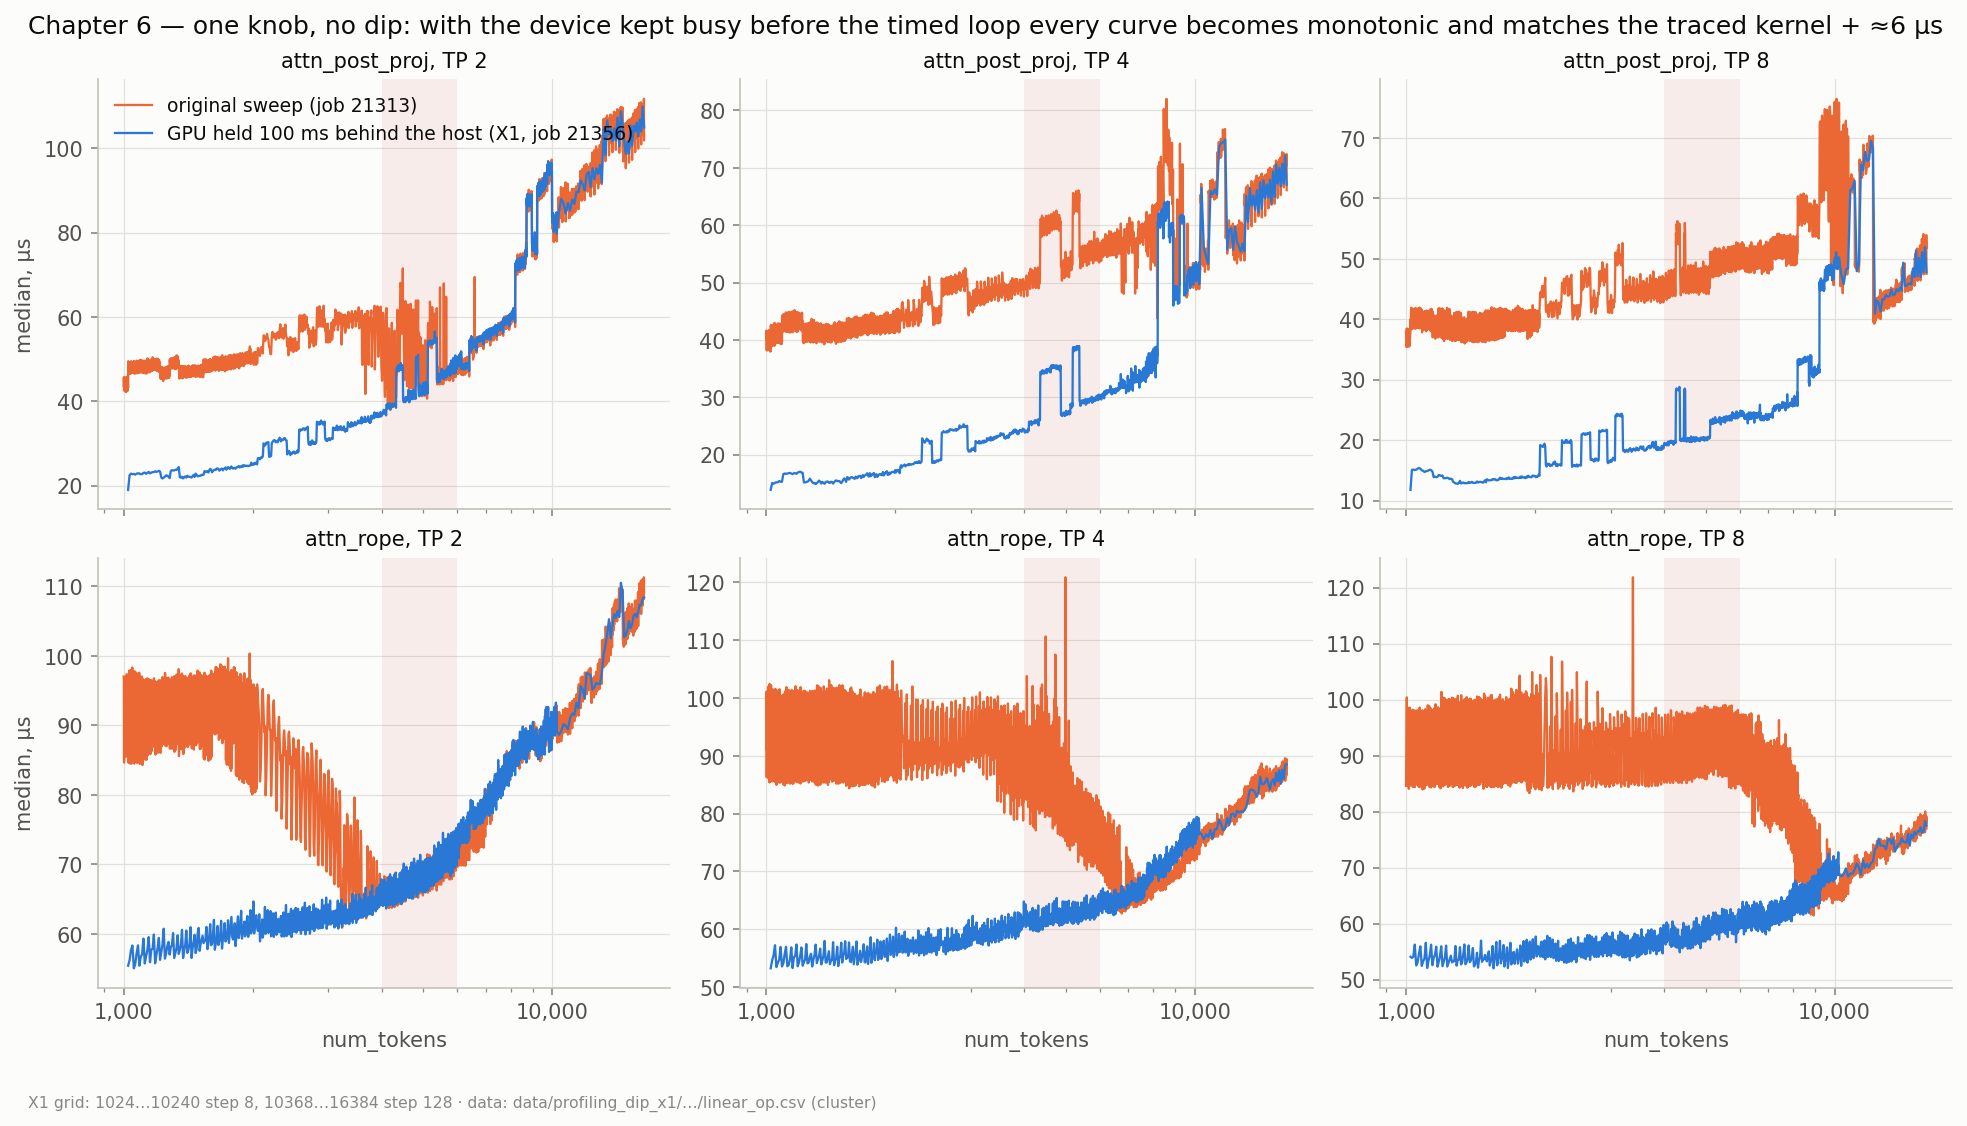

<sub>`f11_dip_original_vs_gpu_backlog.png`</sub>

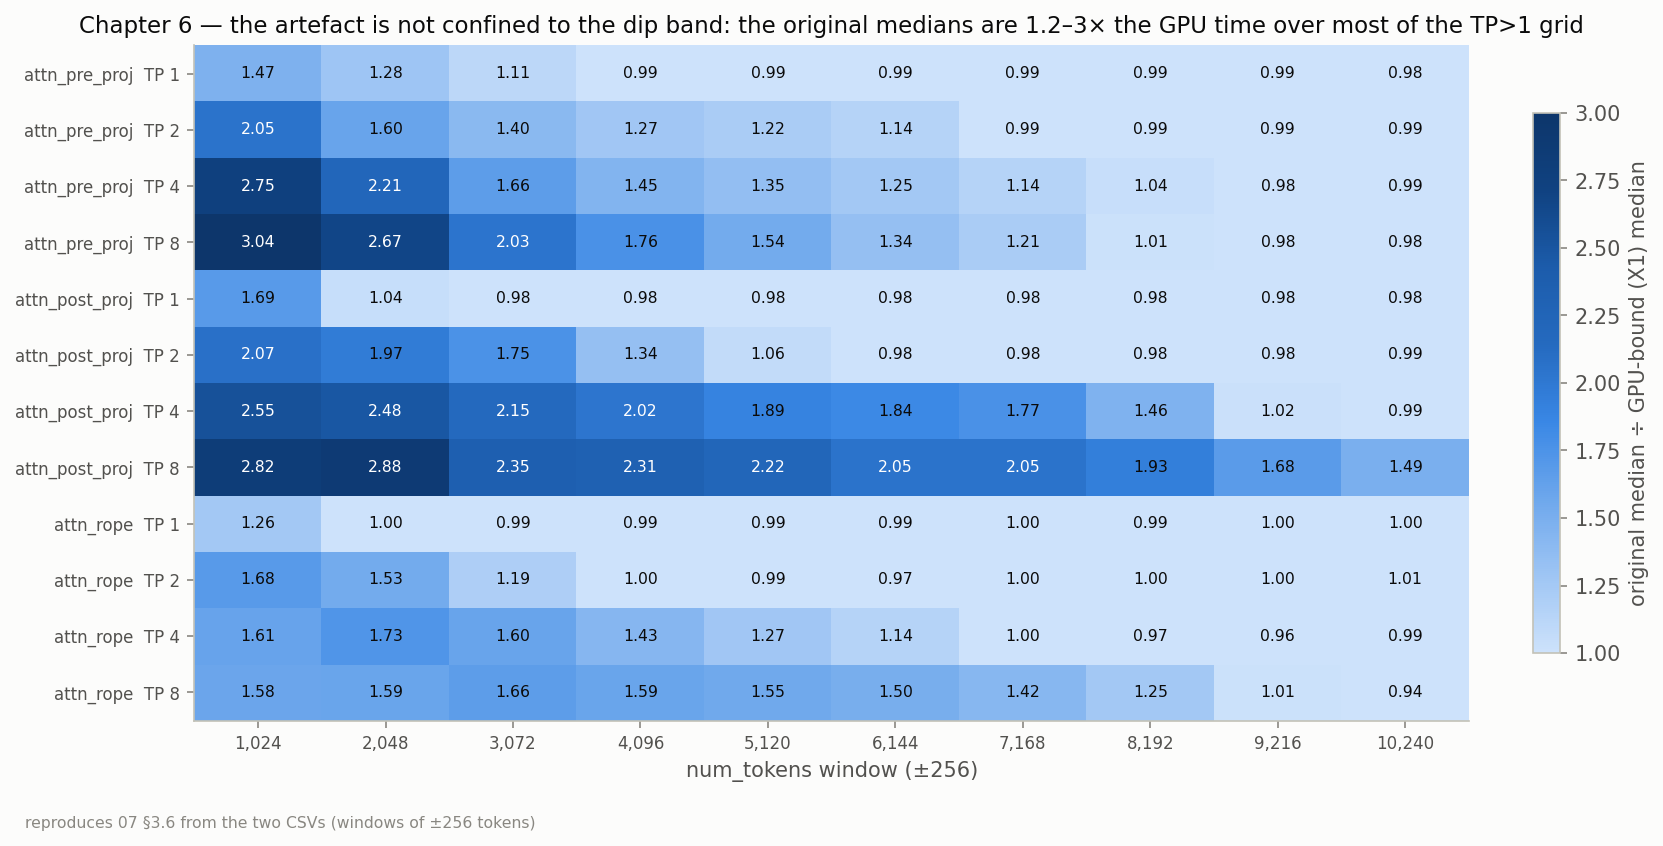

<sub>`f12_inflation_original_over_gpu_bound.png`</sub>

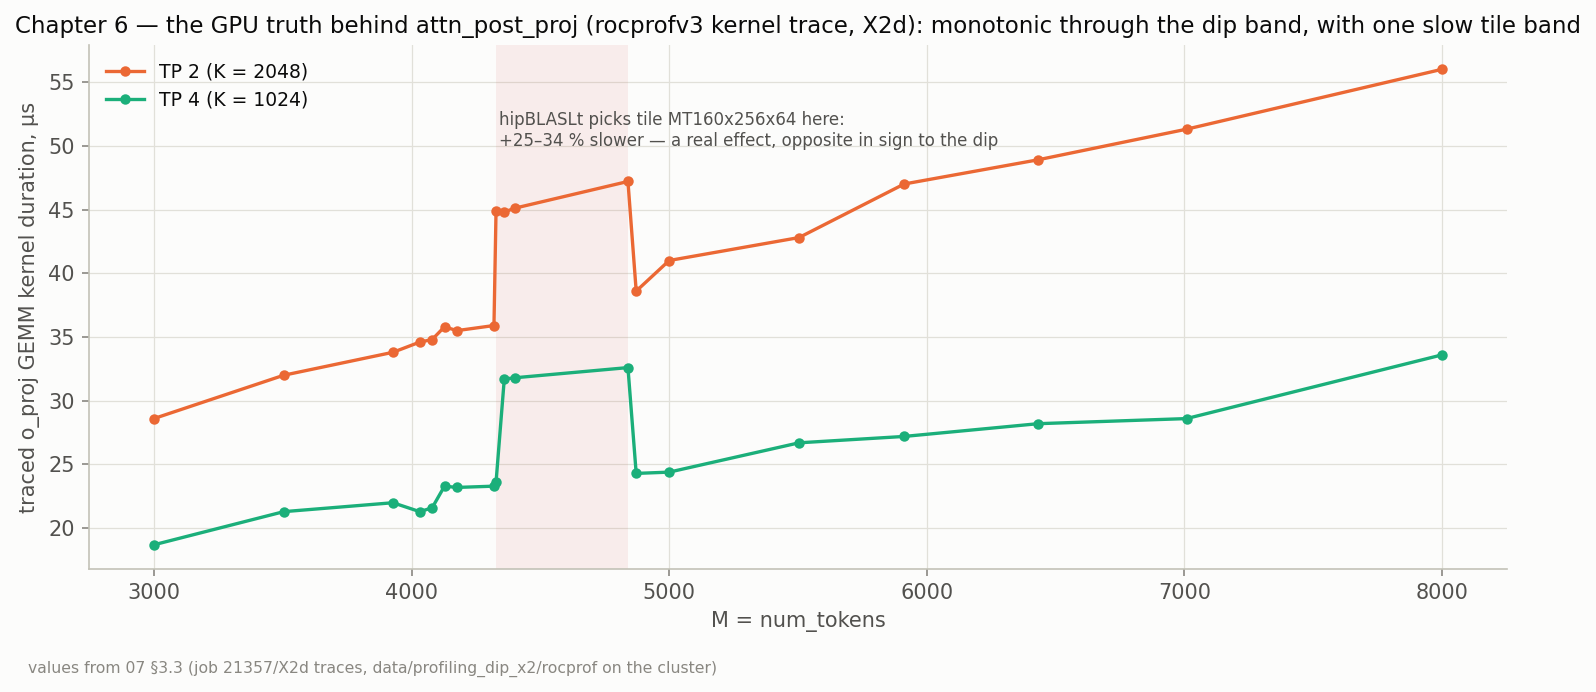

<sub>`f13_oproj_kernel_trace_tiles.png`</sub>

**Why a dip and not a floor.** At small M the device drains everything queued earlier in the forward (QKV GEMM, norms, RoPE
chain, `randn_like`) before the host records `attn_post_proj`'s start event, so the pair reads the host span (≈0.05 ms). As M
grows those preceding kernels grow while the host span does not; the start event begins to be stamped late, the interval
collapses toward the kernel time, and from there it grows with M. The "trough" is set by host speed and the GPU work ahead of
the scope, not by K.

**What the brief got wrong, kept on record (07 §5):** the K-dependence was causally irrelevant; `attn_rope` was not a RoPE
kernel; "normal variance" in the dip rows was actually bimodal; `attn_pre_proj` was affected more than the two ops in the
brief; the "snap back" was the kernel growing plus the slow tile band.

**The RoPE discovery (07 §3.5).** `attn_rope` in every run so far was the pure-PyTorch fallback forced by the collection script
(`FRONTIER_PROFILING_FORCE_TORCH_ROPE_FALLBACK=1`, a cookbook workaround for a supposed `get_rope` signature mismatch): 13
launch-bound torch kernels plus two full copies — and it rotated only the first 64 columns of head 0 of the flattened
tensor, leaving 88–98 % of the elements untouched. It was timing a computation that is not RoPE.

**Decision.** Because the conclusion came from our own judgement, do not act on it yet: **pre-register** the validation.

## 9. Chapter 7 — pre-registration, validation, and the two-column fix

**Pre-registration (`08_`, 2026-09-16 12:31, before any run).** H0 (artefact) and H1 (real GPU effect, possibly clock-related)
each got numeric predictions for three methods — (a) current event timing, (b) event timing with the backlog knob, (c)
rocprofv3 kernel durations — over shapes {1, 8, 64, 3072, 4096, 4192, 6144, 8192} × TP {1,2,4,8}; seven falsification
conditions; a whole-forward closure identity; a contamination detector with predicted sensitivity; a numeric prediction for
the RoPE fallback bug. Monotonicity was never a criterion.

**Results (`09_`, 2026-09-17; jobs 21376–21378).** H0 stands on every decisive number: `attn_post_proj` event ÷ kernel at
8–64 tokens = 3.2–6.9 at every TP (H0 predicted 3–12, H1 0.9–1.1); traced `o_proj` kernel 5.5–12 µs at 8–64 tokens; no-knob ÷
knob kernel ratio 0.98–1.11 (H1-DVFS needed ≥1.15); with the knob, event = traced kernel + 0.3…3.9 µs on all 32 shapes.
Scorecard: 262 of 369 committed numbers inside their bands, 107 outside, misses reported as misses. **F6 fired** (whole-forward
closure), later resolved as instrument mechanics (below). Kept on record: our own acceptance test T1/T3 was mis-specified
(the small-M kernel is weight-read / fixed-cost bound, so no correct instrument could pass it) and was replaced by T1′/T2 with
the argument written out; the pre-registered contamination detector failed its own test and was not wired in.

**The fix — two timing columns (`d4469be`, implement-loop record).** Every shape is now timed twice under `cuda_event`:

| column | what it is |
|---|---|
| `time_stats_hostbound.<op>.*` | the legacy loop, unchanged — documents the host-bound regime |
| `time_stats.<op>.*` | GPU-bound pass: a calibrated device spin (≥3× the legacy loop wall, re-fitted from every measured spin) is enqueued before the timed loop so every event pair measures device time — **the primary column** |
| `time_stats.forward_gpu_span.*` | one event pair around each whole forward (closure check) |
| `legacy_host_bound_ratio.<op>`, `legacy_host_bound.<op>` | legacy ÷ GPU-bound and the > 1.15 flag |
| `host_wall_per_forward_ms*`, `host_enqueue_per_forward_ms*` | host pace per pass |

Validation grid (job 21389, `runs/2026-09-17_0846_…_two_column/`): T1′ legacy ÷ GPU-bound at 8/64 tokens = 2.95–5.3, max
GPU-bound ÷ legacy 1.005, T2 4.56/2.97/2.02 → GREEN; GPU-bound `attn_post_proj` within +0.3…+4 µs of the rocprofv3 kernels.

- `f14_validation_grid_two_columns.png` — legacy vs GPU-bound vs traced kernel, `attn_post_proj`, all TPs.

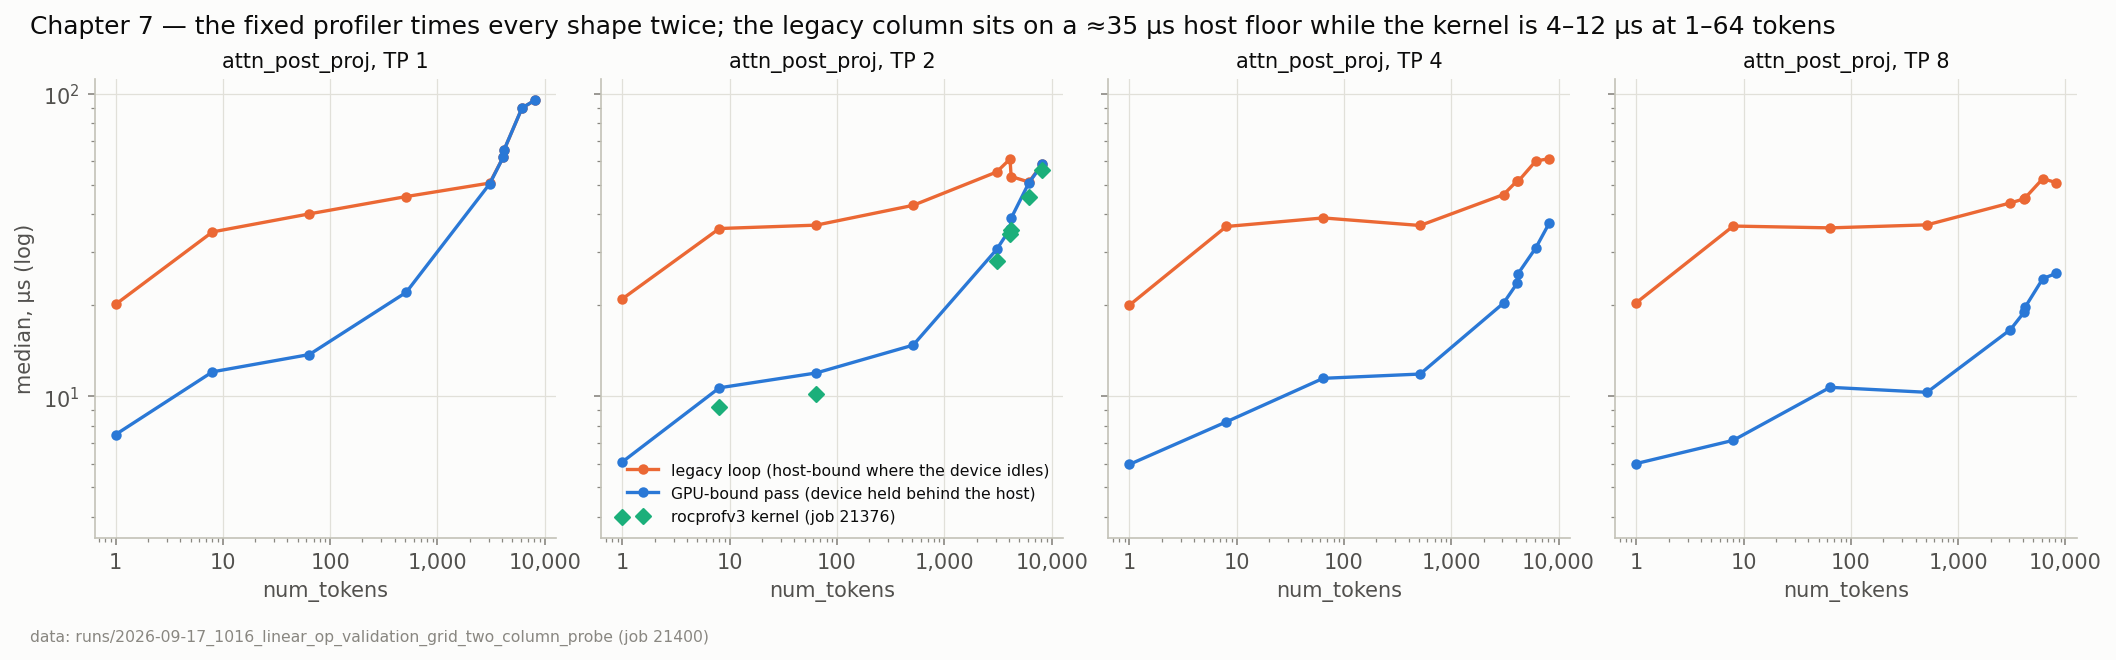

<sub>`f14_validation_grid_two_columns.png`</sub>

**Three follow-ups the same morning (`09_` §3a–3c, `9dac93b`):**

1. **F6 closed.** The 8-token closure residual is HIP command-queue backpressure: with 50 forwards behind one spin the queue
   fills, the host is throttled, and at the fastest forwards the device catches the host before the loop ends. 25 forwards per
   spin close to 0.97–0.99; 100 break everywhere. → recollection must spin blocks of ≤ 25.
2. **Clock lock works** (`rocm-smi --setperfdeterminism 1900`, job 21395): at a locked clock the 5–11 % TP4/TP8 residual
   collapses to the +0.5…+3.6 µs instrument gap — **the residual was clock**. Incident disclosed: the availability probe locked
   one GPU for ≈2 min outside a job before reset.
3. **Warm-up does not warm the clock** (job 21400, `runs/2026-09-17_1016_…_probe/`): a fixed 2M-cycle spin timed by an event
   pair, placed immediately before and after each timed loop, shows the legacy pass **starting at 648–948 MHz on 32 of 36 rows
   after three warm-up forwards and a synchronize**, ramping to ≈2.4 GHz during the loop; the GPU-bound pass runs ≈2.4 GHz
   throughout. So the two columns differ by clock trajectory as well as by queue state. Every row now carries
   `sclk_mhz_{legacy,backlog}_{start,end}`.

- `f15_clock_probe_per_pass.png` — the four probes over the 36 rows.

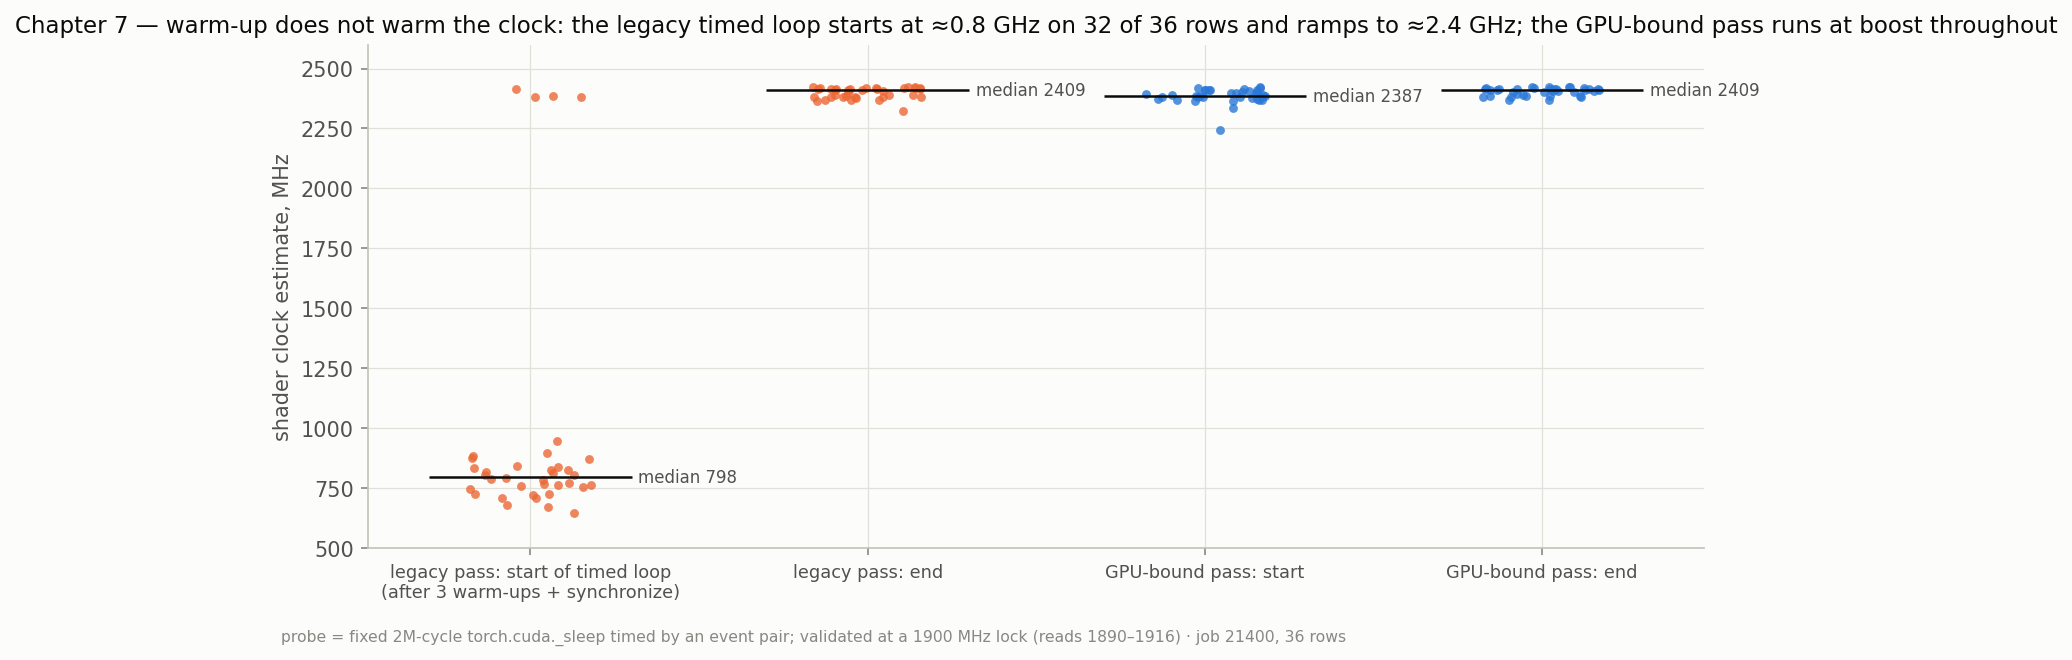

<sub>`f15_clock_probe_per_pass.png`</sub>

Also established: `--profile_method record_function` (kineto kernel-only) works on this image and agrees with rocprofv3
within 2 % for GEMMs; tiny kernels disagree 20–34 % between tracers, so kernels ≤ 10 µs are un-cross-validatable.

**Decision — the measurement contract (`10_`, agreed 2026-09-17 10:55, `ec63f31`).** hetcalc's linear-op term is **(a)
kernel-only device time per op at a stated clock condition, plus a separately measured launch/gap overhead term** — never an
inclusive latency whose kind changes with shape. Kernel term from kernel timestamps cross-checked by GPU-bound events; two
clock conditions (automatic with the probe logged, and a locked-clock baseline); overhead term measured as legacy − GPU-bound
where the legacy loop is host-bound (≈0.020–0.09 ms per scope) plus ≈3 µs per kernel boundary; `attn_rope` excluded until fixed.

## 10. Chapter 8 — RoPE was never RoPE

**Task (`11_`, TASK-1 of the recollection plan, 2026-09-17).** Replace the forced torch fallback. What we found on the way
(jobs 21402–21412, implement-loop record):

- The cookbook premise was wrong for this image: vLLM 0.9.2 in the sglang image accepts Frontier's `get_rope` call.
- But vLLM's own `RotaryEmbedding` on ROCm dispatches `forward_hip → forward_native`: **17 torch kernels, 45–160 µs**, never the
  fused op. An AITER path returned garbage — traced to vLLM's wrapper around AITER, not AITER itself.
- Frontier's own `RotaryEmbedding` calling `vllm._custom_ops.rotary_embedding` launches the fused
  `rotary_embedding_kernel` — the same kernel family SGLang's `forward_hip` launches on this image, timings identical to 0.1 µs
  (4.0/5.6/27.9 vs 4.1/5.5/28.0 µs at 8/512/4096 tokens), numerics identical (max |diff| vs float64 0.017–0.036 in bf16).

**Fix (`4b8fce3`).** `get_rope` prefers Frontier's class with the fused op; the fallback is rewritten per head so it is never
the wrong computation; every row records `attn_rope_impl` (`vllm_kernel` / `torch_fallback` / `vllm_object_<method>`);
`sanity_check.py` rejects anything but `vllm_kernel`; the forced env var is removed from the sbatch; the cookbook gotcha is
corrected. Scope name `attn_rope` kept because the attention trainer requires it.

- `f16_rope_fallback_vs_fused.png` — fallback vs fused kernel (GPU-bound event) vs kineto kernel-only, TP 1 and TP 8: 2–8×
  cheaper, and the event exceeds the kernel-only value by the constant ≈2.5–3 µs record cost.

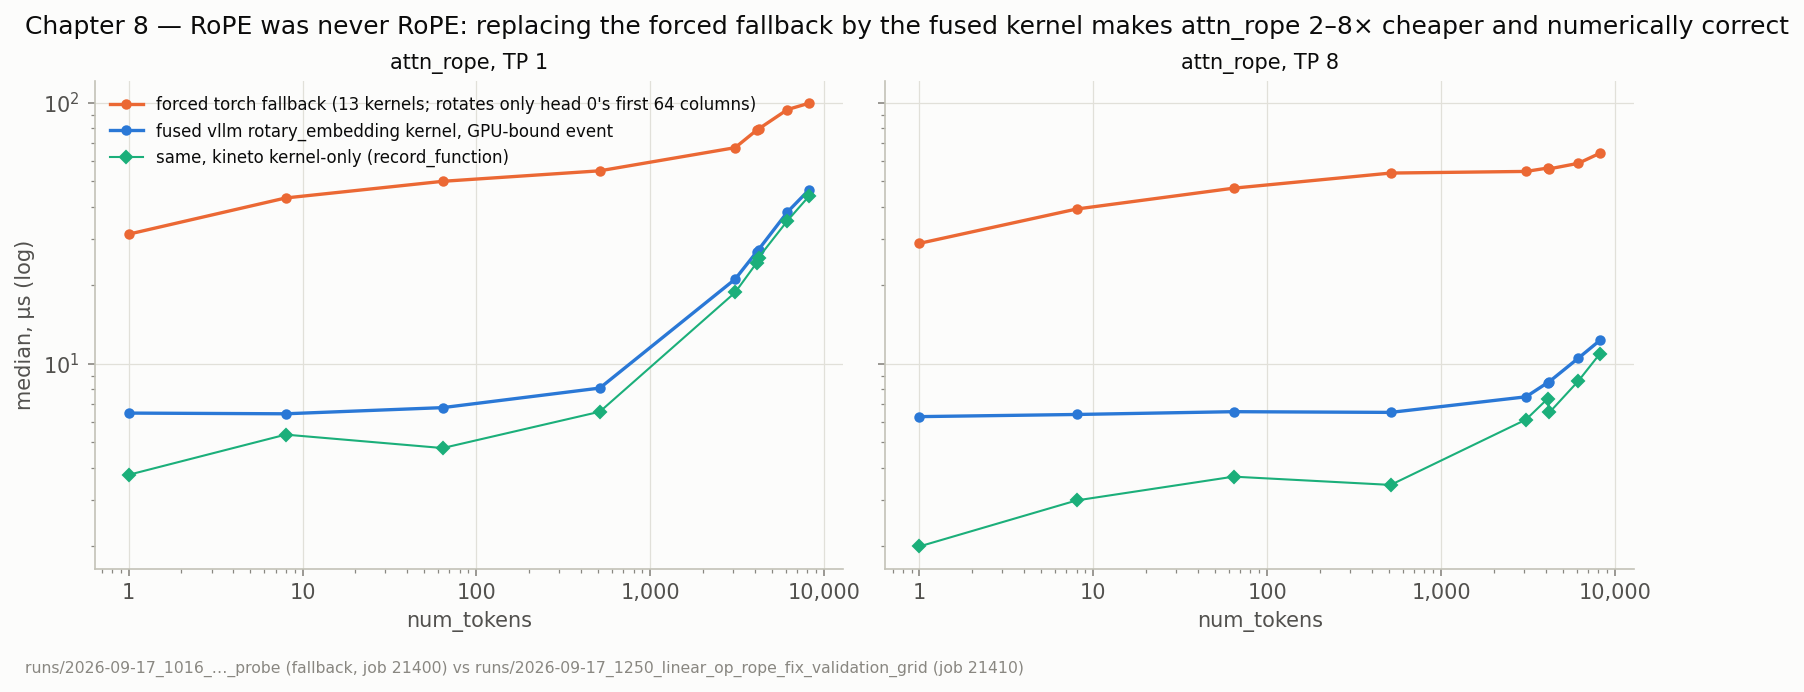

<sub>`f16_rope_fallback_vs_fused.png`</sub>

Also found during this task: `sanity_check.py --data-dir <dir>` produced a vacuous PASS twice (positional path swallowed
the option); now a usage error.

## 11. Chapter 9 — the re-collection with every fix

**Runs (2026-09-22, node `amd-mi355x-1`).** Job 21483: dense grid, 25 timed forwards per shape (3.5 min). Job 21486: 200
forwards as 8 spun blocks of 25 (19 min). Active: two-column timing, spun blocks, clock probe, GC disabled, fused RoPE.
200 ÷ 25 median ratio 1.000 (p1–p99 0.96–1.04): the extra repetitions bought confidence, not different numbers.

- `f17_dense_fixed_gpu_bound_vs_legacy.png` — both columns on every row for the three ops; the gap is the host span.
- `f18_dip_gone_old_vs_fixed.png` — old canonical vs fixed GPU-bound: no dip, no plateaus; costs rise with tokens as a GEMM
  should. Small 15–30 % steps remain at 4352→4360, 4480→4488, 4864→4872, 5376→5384 and ≈11.8k–12.3k (tile switches).
- `f19_old_over_fixed_ratio.png` — how inflated the old data was (median over the grid, `12_` §5):

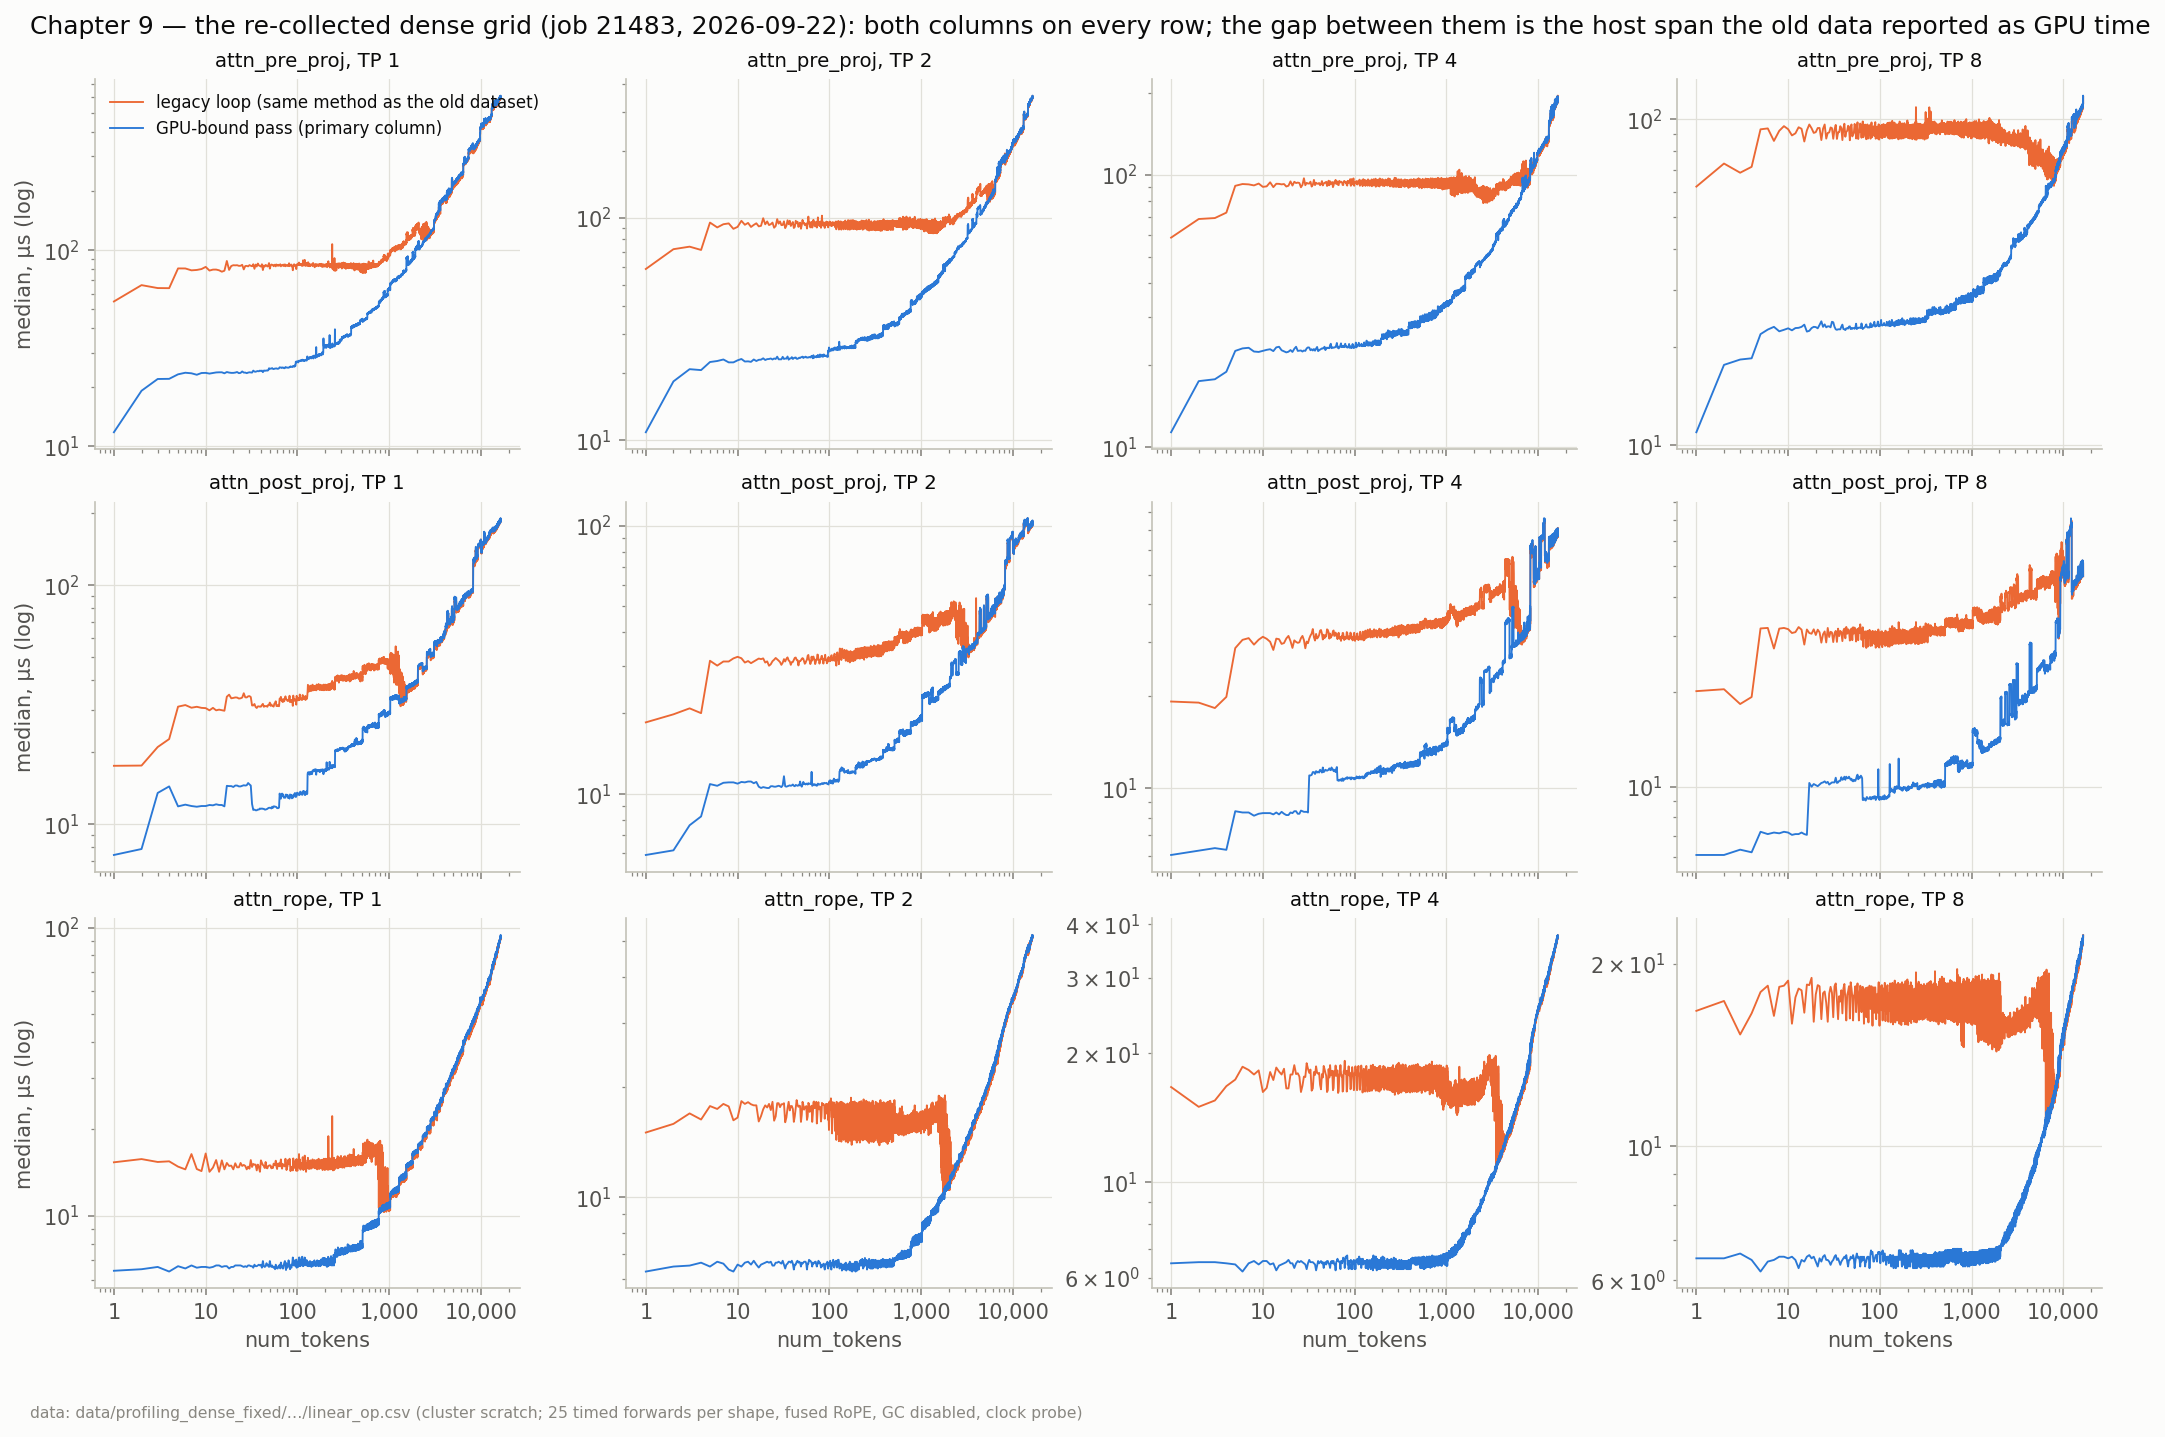

<sub>`f17_dense_fixed_gpu_bound_vs_legacy.png`</sub>

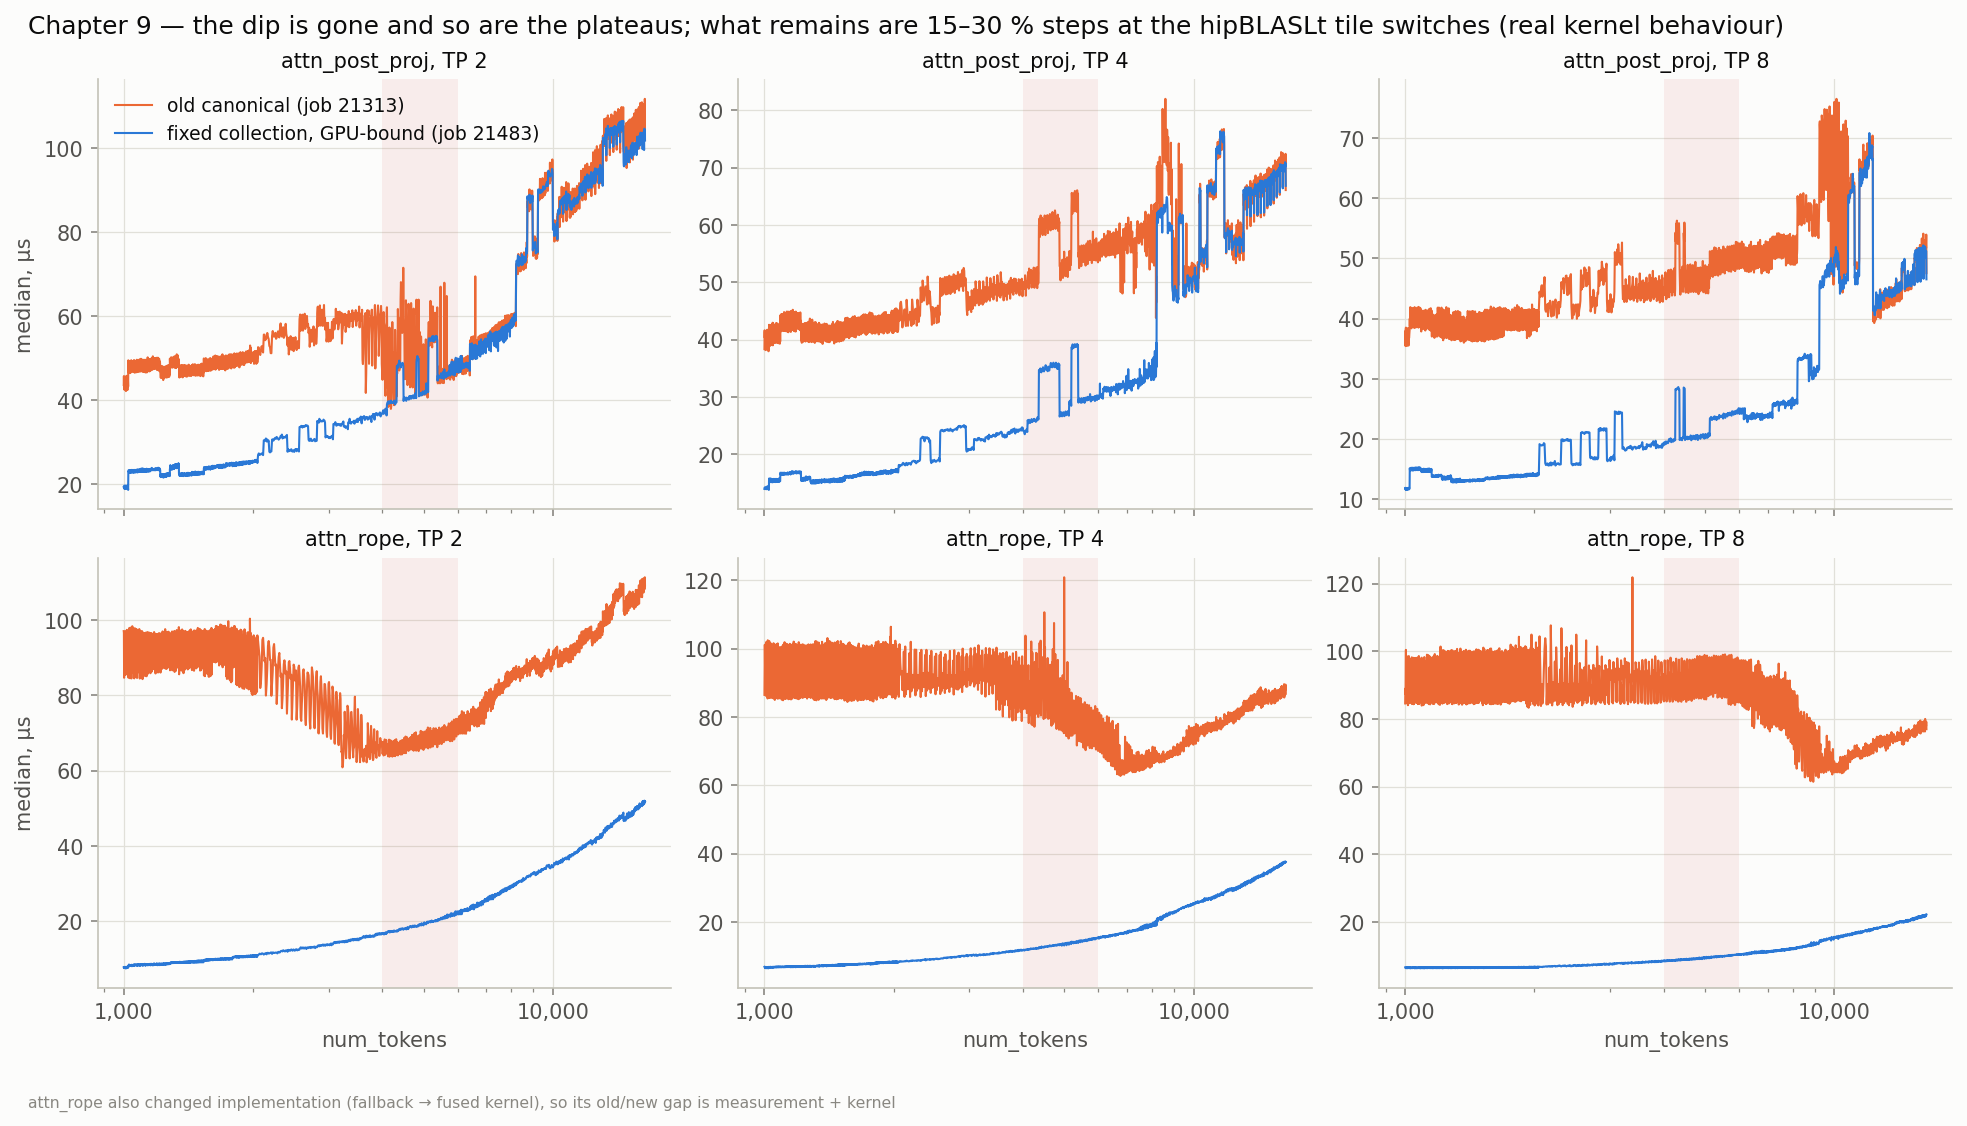

<sub>`f18_dip_gone_old_vs_fixed.png`</sub>

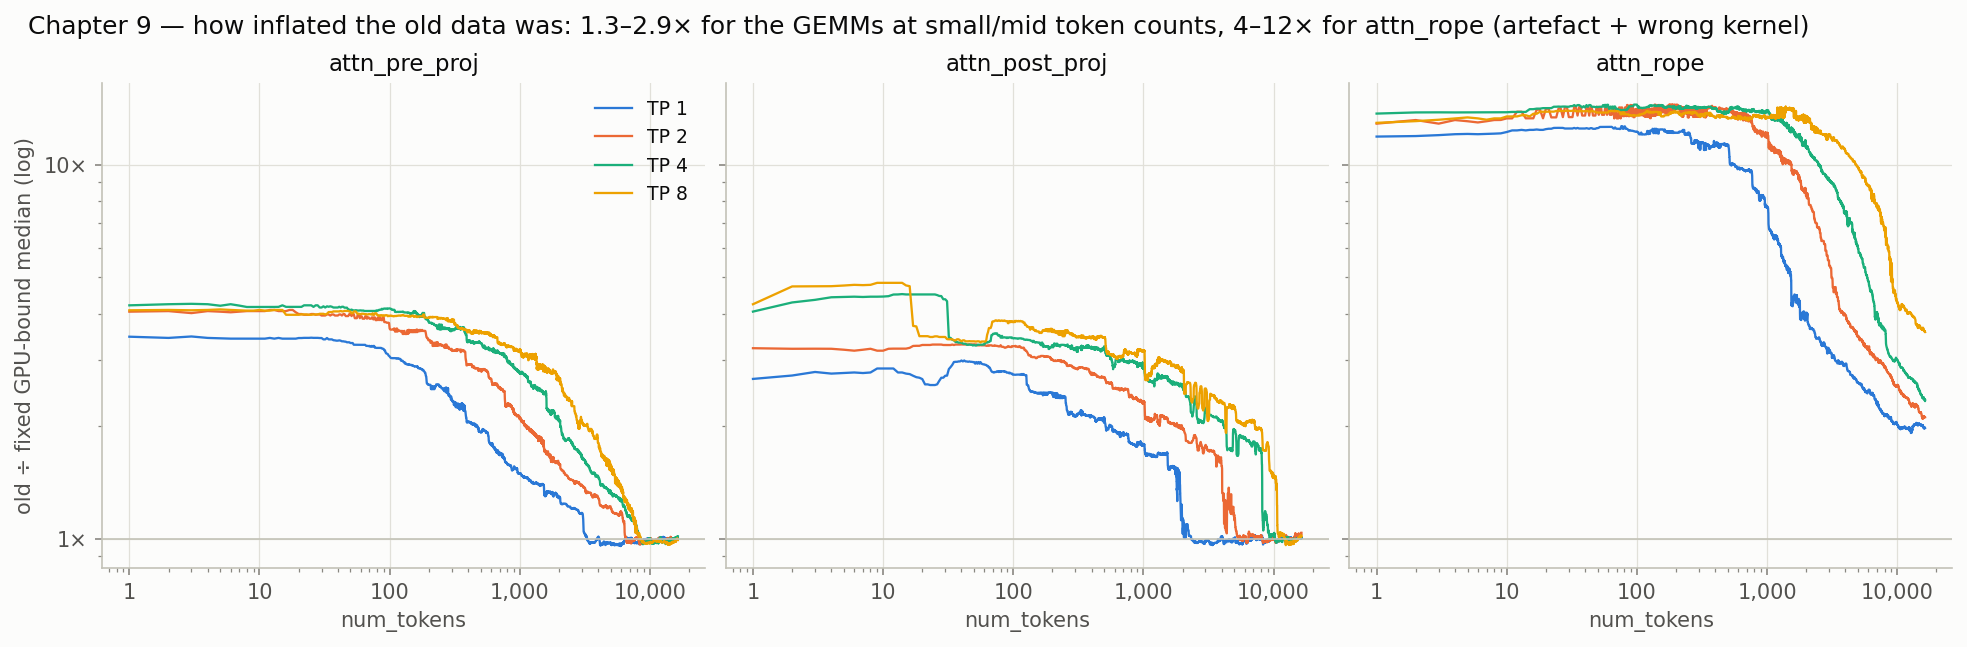

<sub>`f19_old_over_fixed_ratio.png`</sub>

| op | TP1 | TP2 | TP4 | TP8 |
|---|---|---|---|---|
| attn_pre_proj | 1.3× | 1.7× | 2.3× | 2.8× |
| attn_post_proj | 1.6× | 2.0× | 2.6× | 2.9× |
| attn_rope | 4.3× | 9× | 12× | 12× |

- `f20_tile_steps_zoom_fixed.png` — the tile-switch steps in the fixed data (real kernel behaviour a cost model must keep).
- `f21_collection_diagnostics_fixed.png` — clock probe ≥2.2 GHz on 13,305/13,308 rows; spin delivered 0.97–1.03 of requested.
- `f22_stall_gone_200_reps.png` — over 200 samples per row no `attn_pre_proj` row has a sample above 10× its median (old
  file: 47 rows, worst 268 ms); worst single sample anywhere 0.74 ms.

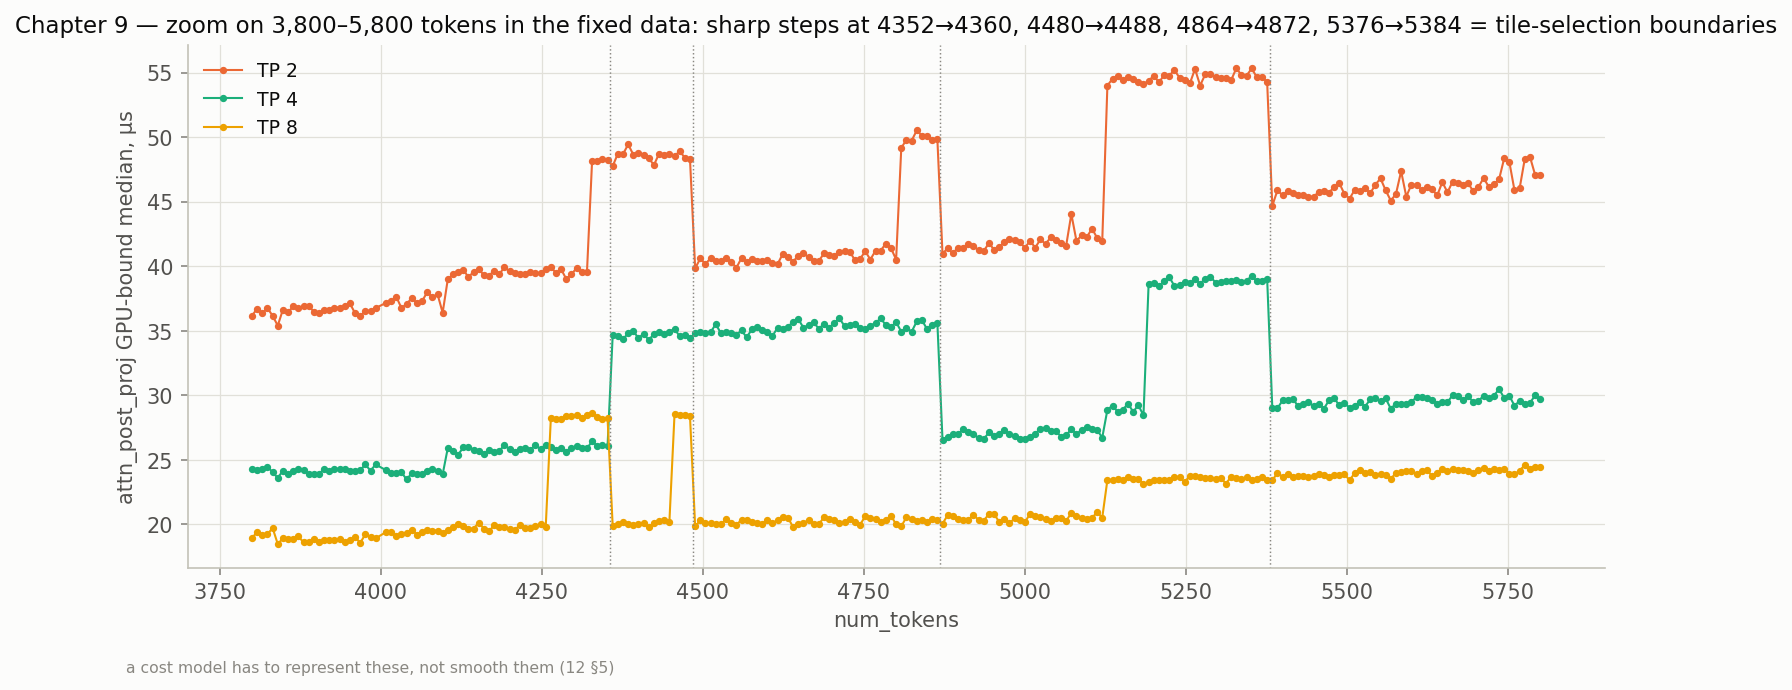

<sub>`f20_tile_steps_zoom_fixed.png`</sub>

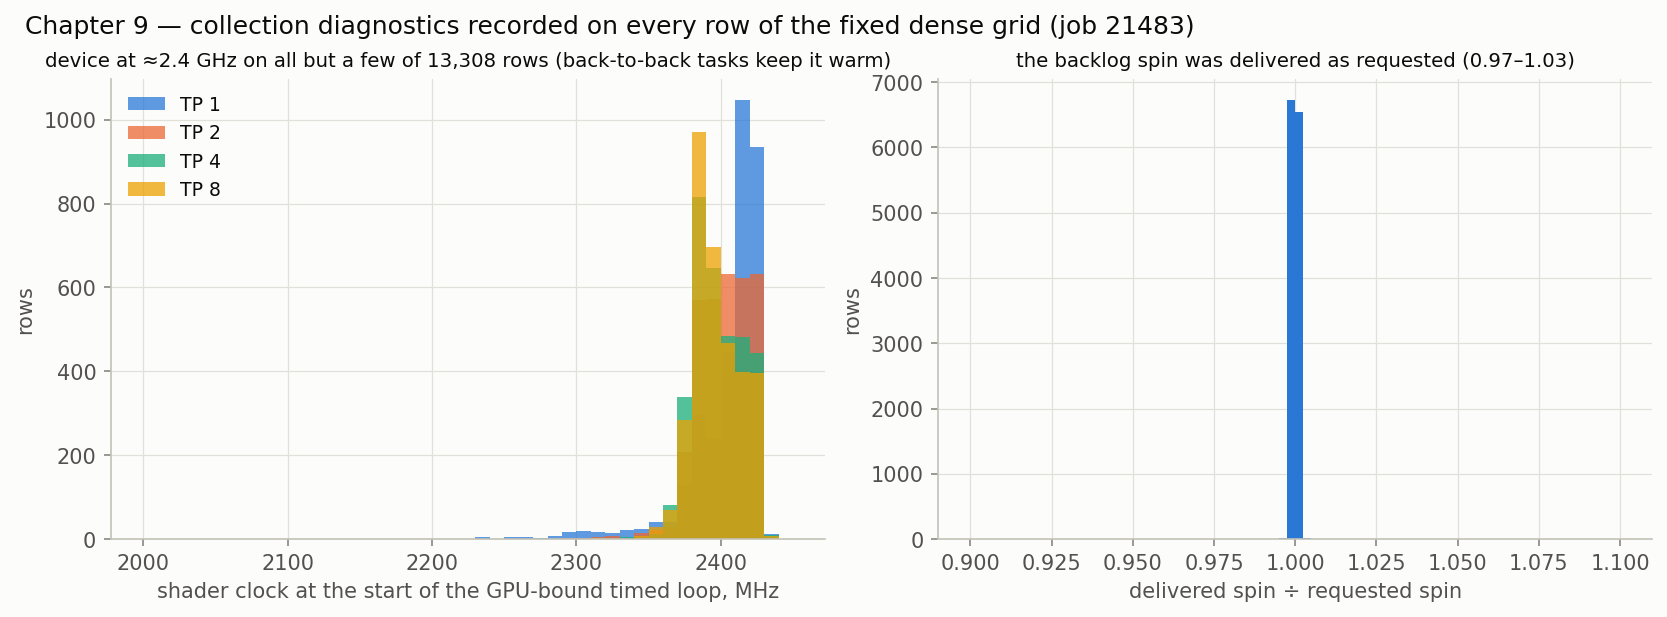

<sub>`f21_collection_diagnostics_fixed.png`</sub>

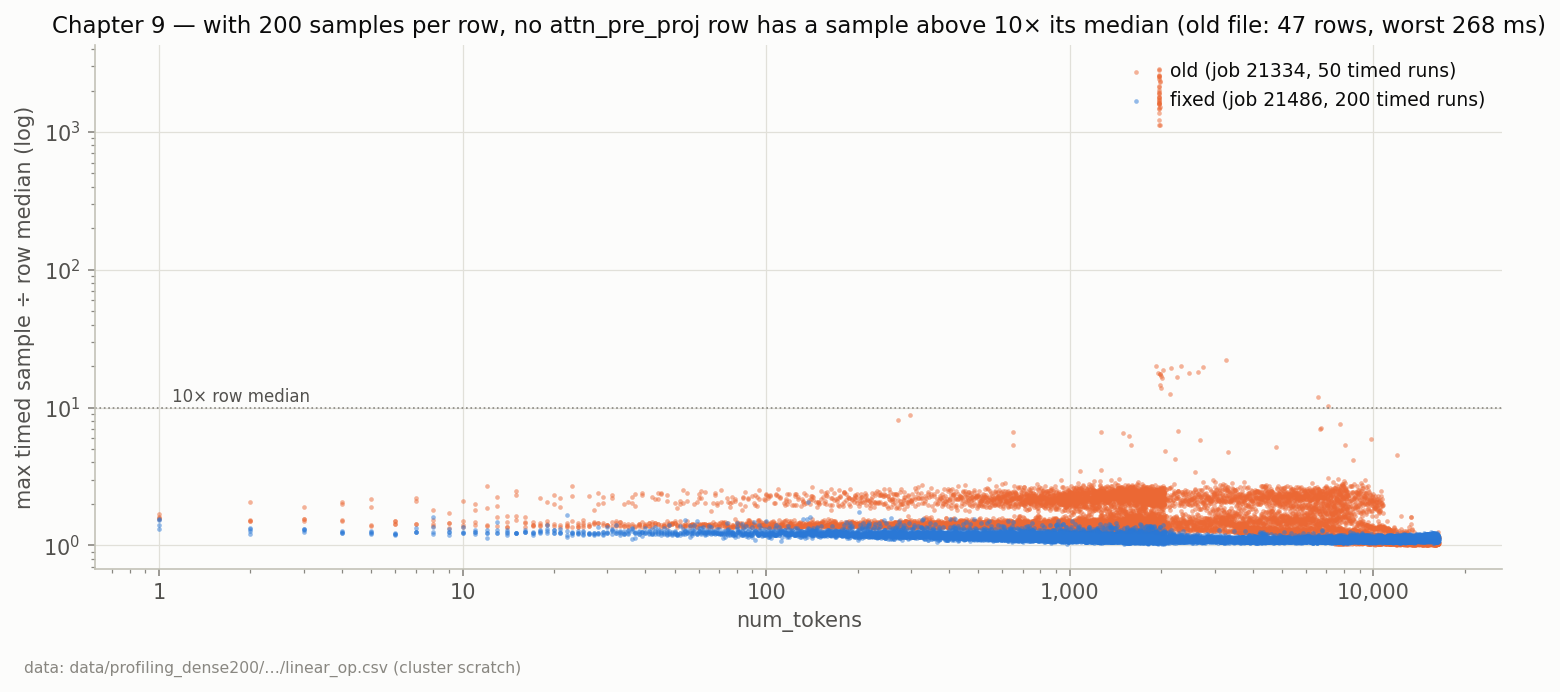

<sub>`f22_stall_gone_200_reps.png`</sub>

**One gate still trips, and it is the gate:** the checker's `GPU-bound ≤ 1.05 × legacy` rule (set on 32-row grids) is exceeded
on 875 rows, mostly TP1 at 1.5k–14k tokens where the *legacy* loop sits at the host/device crossover and its samples are
bimodal while the GPU-bound samples are flat. Recommendation: 1.10 with the reason recorded.

**Status.** These CSVs live in the cluster scratch tree (`data/profiling_dense_fixed/`, `data/profiling_dense200/`), not yet
staged as run dirs; the canonical `linear_op.csv` is still the 2026-09-15 collection. The three notebooks under `viz/` render
the old data, the new data and the old-vs-new decomposition (recollection effect vs fix effect).

## 12. Chapter 10 — run-position anomalies in the fixed data

**What we saw.** In the per-run plots of the new collections two patterns: (1) the last run of every 25-run block tends to be
the minimum; (2) at TP>1 `attn_pre_proj` has its maximum at run 20 in 42–60 % of rows (and at run 118 in the 200-rep file).

- `f23_position_profile_fixed_25.png` — position profiles of the GPU-bound and legacy columns, job 21483.
- `f24_position_profile_200_reps.png` — the 200-rep file: the ramp restarts after every spin; barrier hits at the predicted
  positions 20, 40, 59, 79, 98, 118, 138, 157, 177, 196.

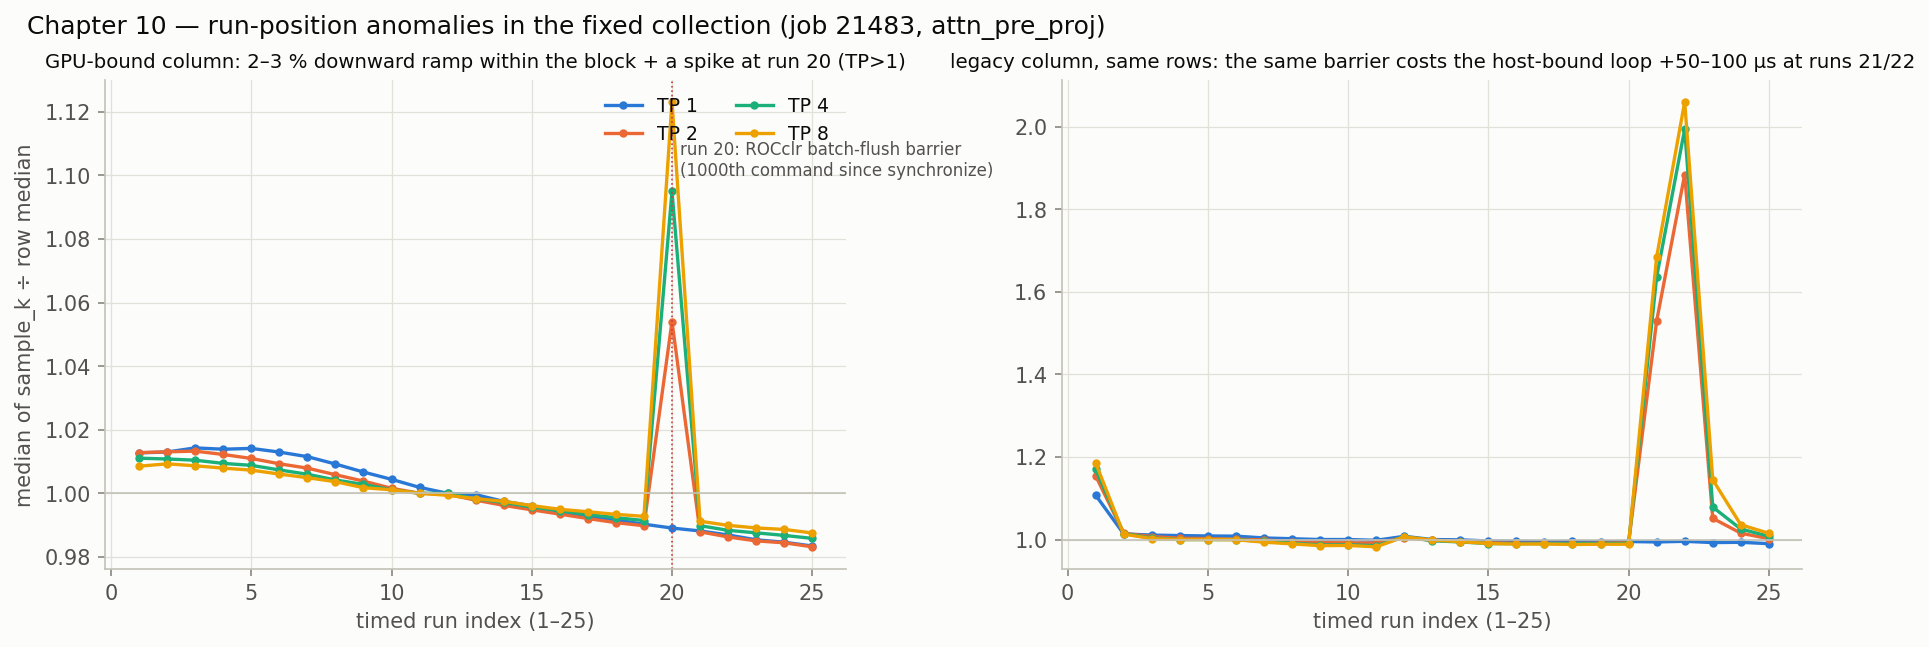

<sub>`f23_position_profile_fixed_25.png`</sub>

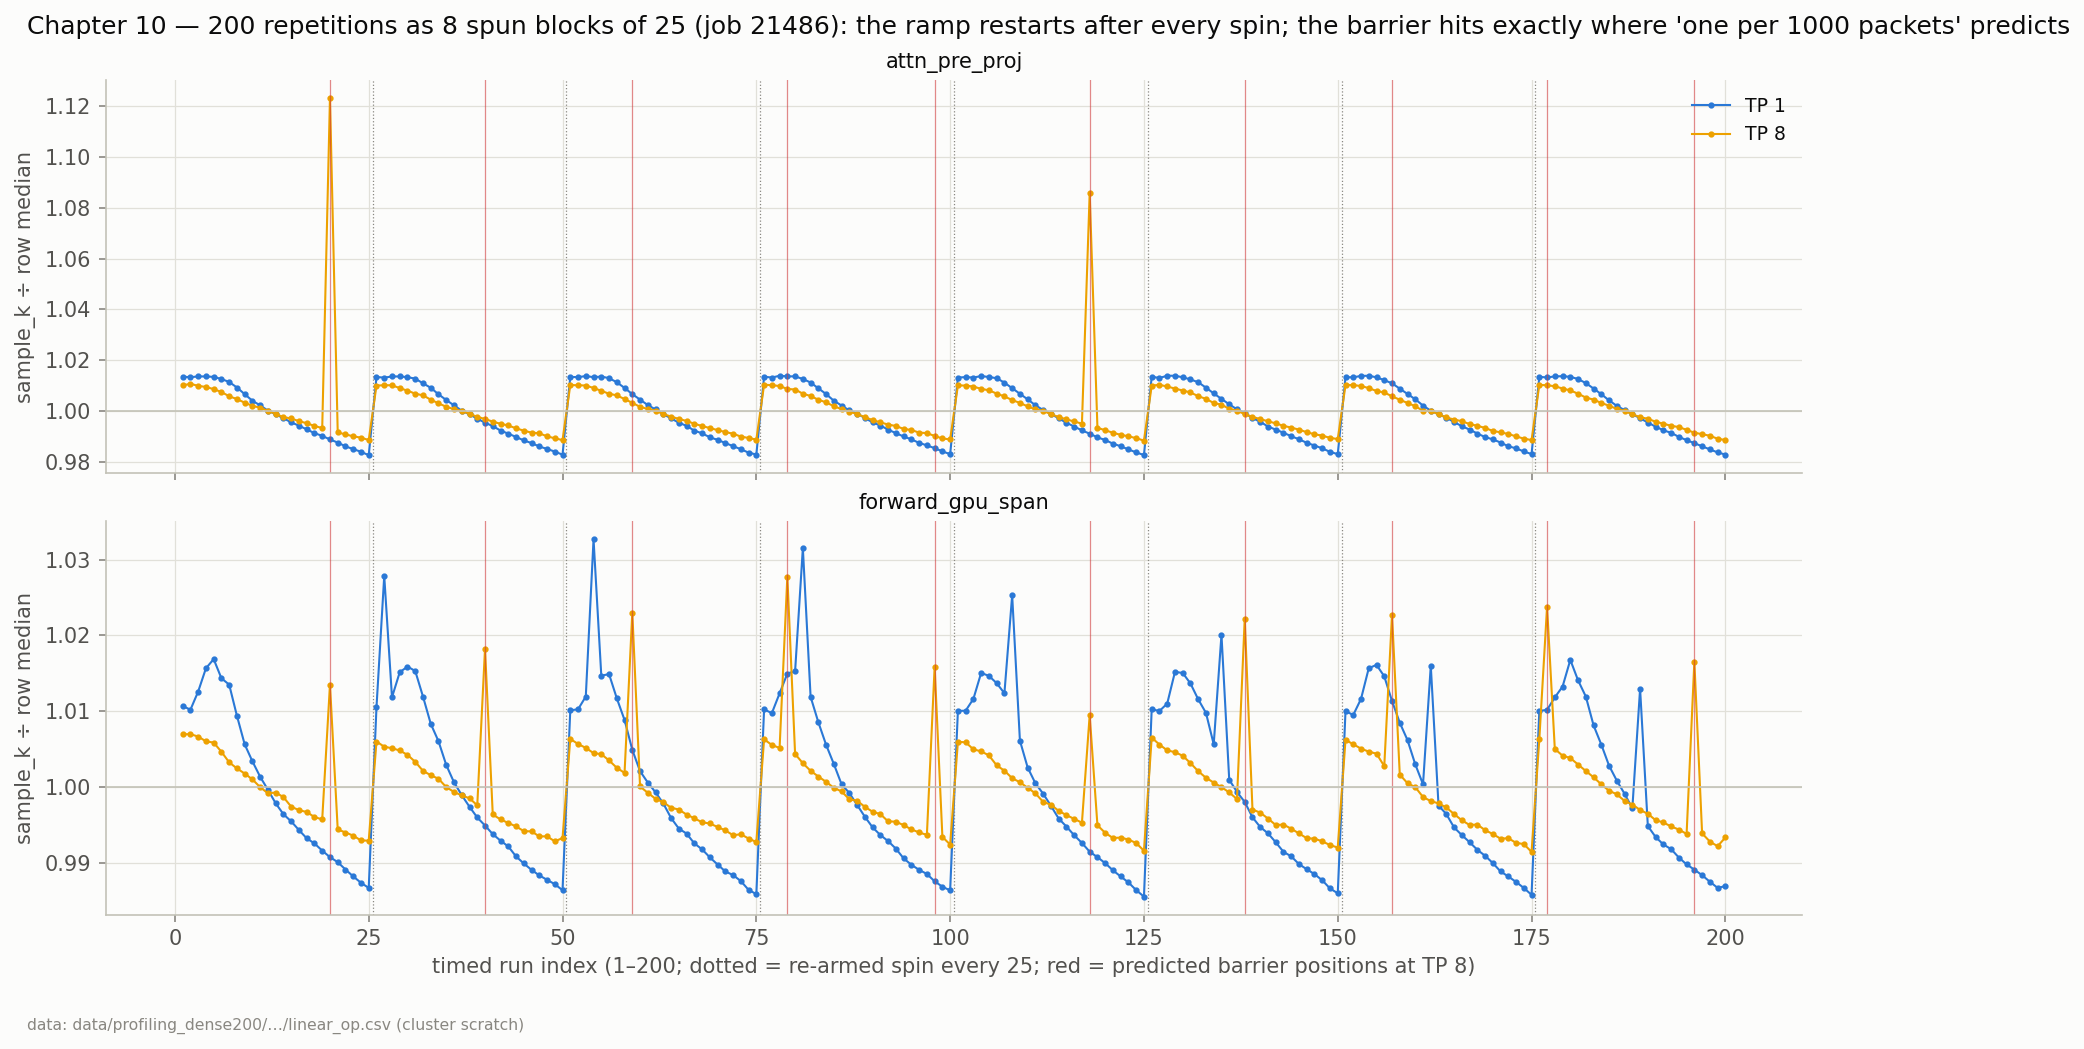

<sub>`f24_position_profile_200_reps.png`</sub>

**Root cause (`13_`, 2026-09-22, jobs 21491–21495, single-process probe `posprobe.py`).**

*Effect 1 is a within-block drift, not a boundary event*: samples decline monotonically 2–8 % from run ~3 to run 25 of every
block. **Cause: the `torch.cuda._sleep` spin** used as the backlog. Replacing it with an equal-length chain of real GEMMs
removes the drift (early/late 1.079 → 1.001 at TP1/6144 tokens); a device-side shader-clock probe after every forward shows
the clock rising ≈1.5 % (2290 → 2330 MHz) over the first 10–15 forwards after a spin — about a third of the drift; the rest is
speculatively another DPM domain (memory/fabric clock) the probe cannot see.

- `f26_clock_ramp_after_spin.png` — the probe series and the spin-vs-GEMM-backlog profiles.

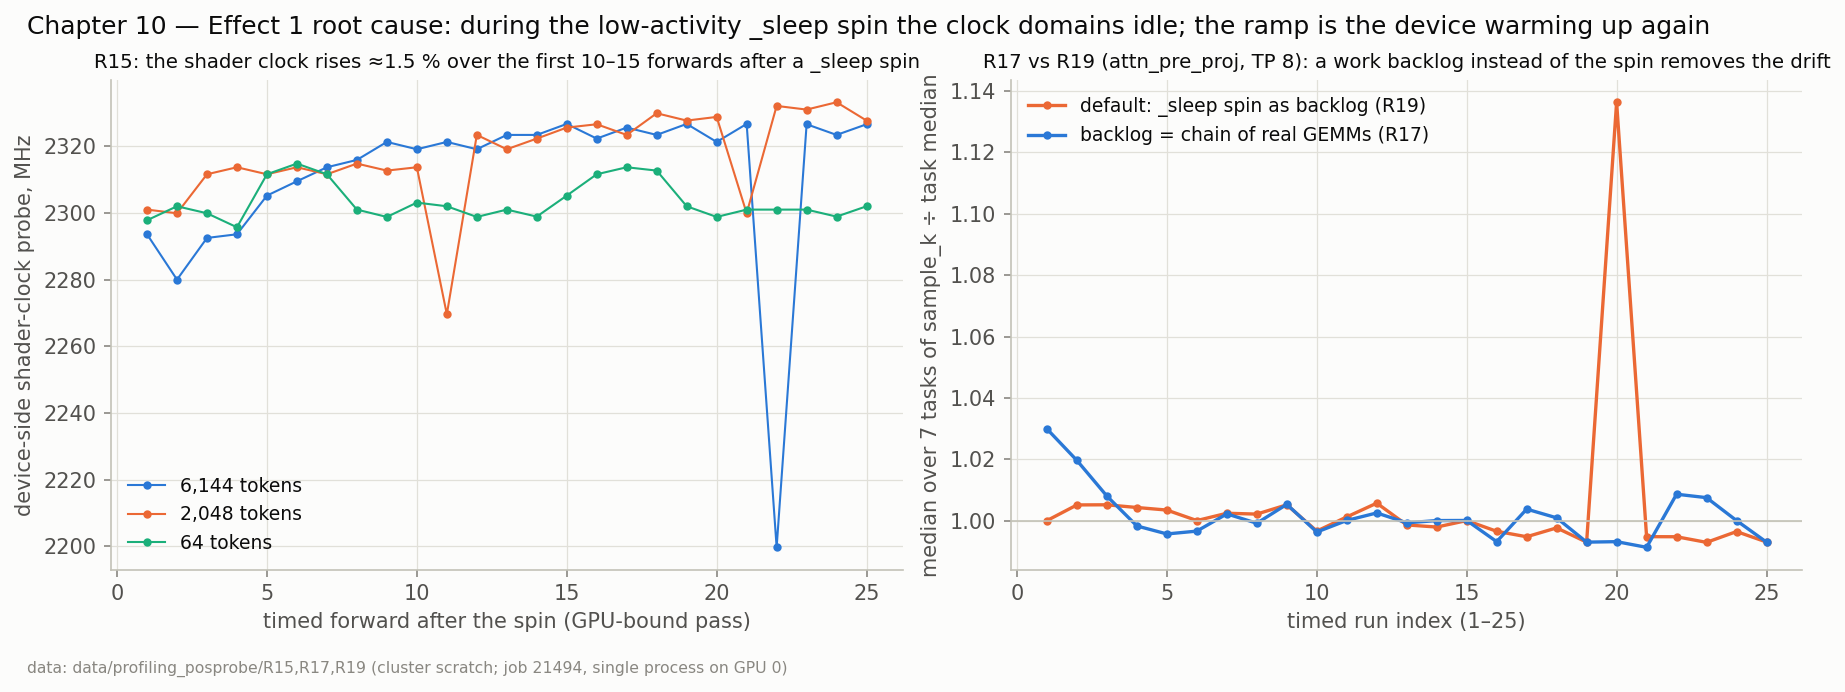

<sub>`f26_clock_ramp_after_spin.png`</sub>

*Effect 2 is the ROCm runtime*: ROCclr's `HostQueue::FlushSubmissionBatch` enqueues a clean-up marker after every 1000
commands since the last synchronize (`DEBUG_CLR_MAX_BATCH_SIZE = 1000`); on the device it is a barrier-AND packet with
system-scope acquire/release fences costing ≈5.5 µs, inside whichever scope holds the 1000th packet. With 29 kernels + 22 event
records per forward at TP>1, that is the copy kernel before k-norm in forward 20's `attn_pre_proj`. Confirmed kernel-by-kernel
in a rocprofv3 trace (one 5.5 µs gap, nowhere else), in the runtime log (`BarrierAND` after 1003 packets, inside a
`hipLaunchKernel`), in the ROCclr source, and by three pre-stated falsification tests (extra warm-ups, extra host time, a
349-packet GEMM backlog each moved or did not move the hit exactly as a packet count predicts). Same event as the legacy
column's +50–100 µs stalls at runs 21/22.

**Fix (addendum to `13_`, jobs 21499 + 21500).** `DEBUG_CLR_MAX_BATCH_SIZE=1000000` in the container. Validation: run-20 sample
997 permille vs 1132 in the same-job control; no legacy stall at 21/22; the runtime log shows only synchronize and
kernarg-chunk barriers. A full 25-rep dense grid with the flag (`data/profiling_dense_fixed_batchflush/`): `attn_pre_proj`
argmax at run 20 drops from 42–60 % to baseline, medians agree with job 21483 to 1.000 (p1–p99 0.96–1.05), Effect 1 unchanged.

- `f25_batchflush_before_after.png` — profiles before/after the flag, both columns.

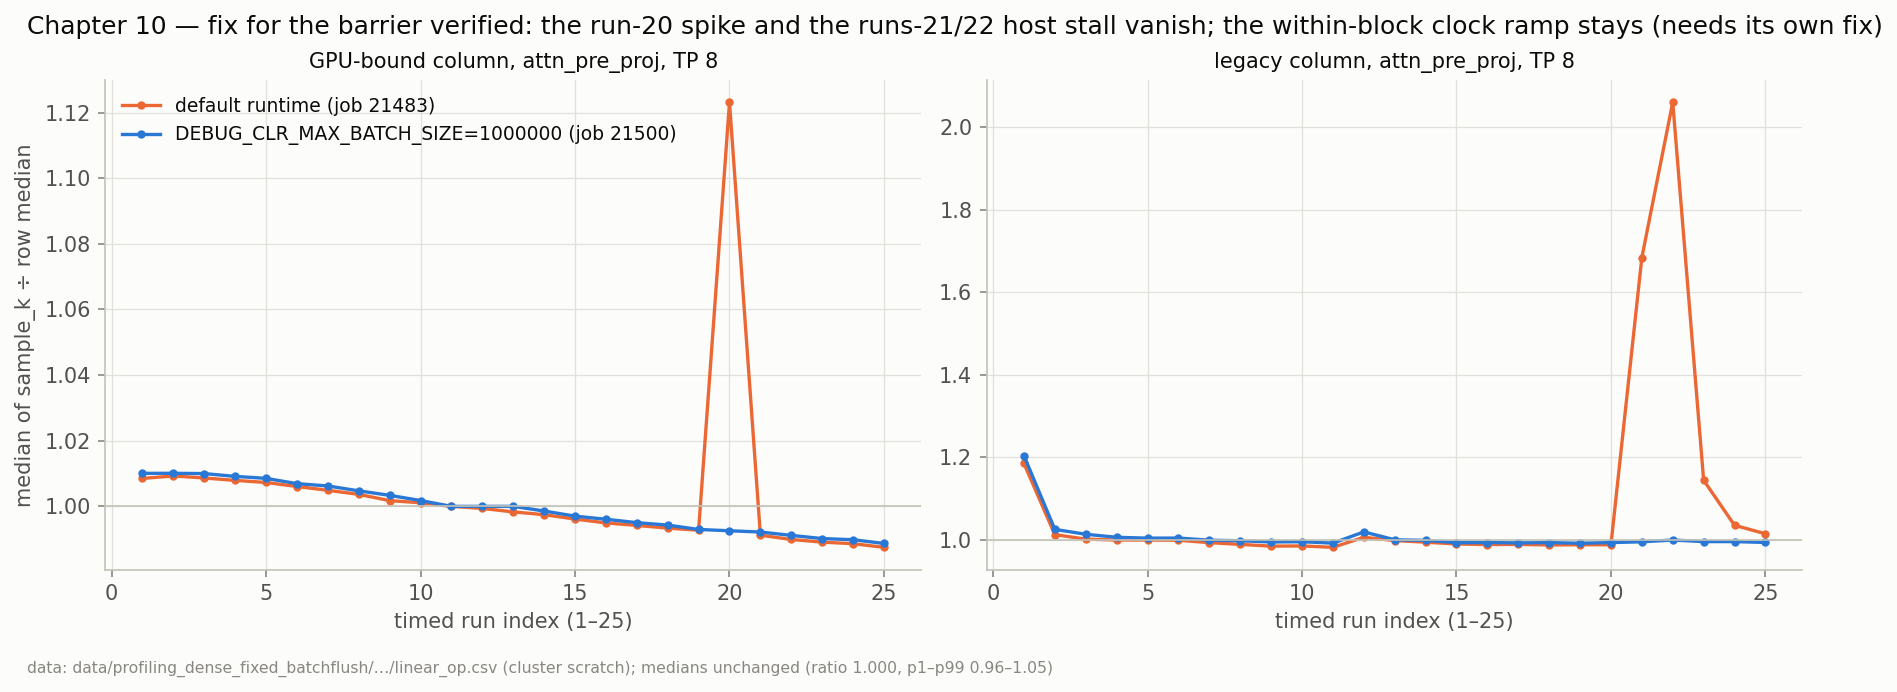

<sub>`f25_batchflush_before_after.png`</sub>

**Open:** Effect 1's fix (untimed forwards after the spin, or a work backlog) is proposed, not run; medians are only marginally
affected (mid-ramp value), min/max/mean/std carry both effects.

## 13. The fixes, in one table

| fix | mechanism | where | validated by |
|---|---|---|---|
| Keep every run in order (50 + 3) | `time_stats.<op>.samples`, `warmup_count` | `deef568` | made all three investigations possible |
| GC disabled around the timed loop | `gc.disable()`/`gc.enable()` in `LinearOpWrapper.profile` | `74eee7c` | jobs 21361/21362 vs 5 criteria; dense 200-rep worst sample 0.74 ms |
| Two timing columns | legacy pass + GPU-bound pass behind a calibrated device spin; ratio + flag per row | `d4469be` | pre-registered validation (`08_`/`09_`), job 21389 GREEN |
| Spun blocks of 25 | spin re-armed every 25 forwards so any repetition count stays device-bound; `forward_gpu_span` closure per row | `4b8fce3` | 25/50/100-forward test (job 21396); closure 0.96–0.99 on the dense grid |
| Clock probe on every row | 2M-cycle spin timed by an event pair before/after each timed loop | `9dac93b` | 1900 MHz lock reads 1890–1916 (job 21395) |
| Fused RoPE kernel | `get_rope` prefers Frontier's class + `vllm._custom_ops.rotary_embedding`; per-head fallback; `attn_rope_impl` column | `4b8fce3` | kineto traces: 1 kernel per scope; numerics vs float64; job 21410 |
| Checkers | full two-column schema, probe group, rope gate, coverage ≥ 3×, `test_measurement_validity.py --expect red\|green`; positional path | `d4469be`, `4b8fce3` | vacuous-PASS bug caught by review |
| Measurement contract | kernel time at a stated clock + separate overhead term | `10_`, `ec63f31` | agreed by the dataset owner |
| Batch-flush barrier out of the timed loop | `DEBUG_CLR_MAX_BATCH_SIZE=1000000` in `LINEAR_DOCKER_ENV` | uncommitted (`13_` addendum) | jobs 21499, 21500 |

Things we believed and had to retract are listed in `12_` §3 and `07_` §5 / `13_` §6; they belong on the page as much as the fixes.

## 14. Still open (as of 2026-09-22)

- Effect 1 (within-block drift after the spin): fix proposed, not run; a memory/fabric-clock sampler would settle the remainder.
- Kernels below ≈10 µs (small GEMMs at TP4/TP8, RoPE below ≈3k tokens, the norms) sit inside the instrument's ≈3 µs floor and
  are not cross-validated between event pairs and traces.
- Locked-clock dense dataset (the contract's second clock condition) not collected.
- Canonical instrument choice (event-pair kernel time vs kineto kernel-only) pending the agreement analysis.
- The 2026-09-22 collections are cluster scratch, not staged run dirs; the trainer still points at the 2026-09-15 file.
- Checker gate 1.05 → 1.10 (with reason) not yet applied.
- Attention datasets (16k/32k/64k) were validated but never had the linear_op-style per-run scrutiny.

## 15. Source index

**Documents (in order of the story):** `00_requirements_and_source_map.md`, `01_plan.md`, `review/*` (plan iterations, 2026-09-10/14),
`02_run_record.md`, `03_linear_op_spike_investigation.md`, `04_linear_op_spike_specialist_brief.md`, `05_linear_op_spike_root_cause.md`,
`data/profiling_gcfix/RUN.md`, `06_post_proj_rope_dip_specialist_brief.md`, `07_post_proj_rope_dip_root_cause.md`,
`08_measurement_validation_preregistration.md`, `09_measurement_validation_results.md`, `10_measurement_contract.md`,
`11_attn_rope_task.md`, `12_dip_investigation_summary.md`, `13_run_position_anomalies_root_cause.md`,
`run_position/README_dense_fixed_batchflush.md`; dataset `README.md` and every `runs/*/RUN.md`;
`~/amd-playground/.claude/debug-reports/debug_linear_op_host_bound_timing_2026-09-16.md`,
`implement_linear_op_two_column_timing_2026-09-17.md`, `implement_linear_op_recollection_2026-09-17.md`;
`~/amd-playground/.claude/plans/linear-op-recollection-contract-a.md` (+ `.iterations.md`).

**Existing interactive plots (Plotly JSON embedded in the notebooks; no PNGs):**
- `viz/linear_ops_run_groups_and_stats.ipynb` — old data (job 21313): per op × TP, run-group means/medians/envelopes and the
  overall summary, each with an auto-filtered companion; 120 figures. The dip is visible in the `attn_post_proj`/`attn_rope`
  summaries; the run-11 stall is masked (34 samples).
- `viz/linear_ops_dense_fixed_run_groups_and_stats.ipynb` — fixed data (job 21483): same plots + collection diagnostics,
  GPU-bound vs legacy overlays, host-bound ratio; 184 figures.
- `viz/linear_ops_old_vs_fixed_comparison.ipynb` — old vs new-legacy vs new-GPU-bound overlays and the three-way ratio
  decomposition (recollection effect vs fix effect vs net); 30 figures.
- `viz/newplot.png` — one exported summary plot (`attn_pre_proj` TP8, auto-filtered, old data).

**Data (repo):** canonical `data/profiling/compute/mi355x/qwen3-a3b-30b-moe/linear_op.csv` (job 21313); `runs/…dense3327_rerun`
(21334); `runs/…grid386` (21309); `runs/legacy_pre-2026-09_torch-sdpa/`; `runs/2026-09-17_0846_…two_column` (21389);
`runs/2026-09-17_1016_…probe` (21400); `runs/2026-09-17_1250_…rope_fix` (21410); `data/profiling_gcfix/` (21361, untracked).

**Data (cluster only, `/opt/shared/frontier-qwen3-profiling/Frontier/data/`):** `profiling_dense_fixed/` (21483),
`profiling_dense200/` (21486), `profiling_dense_fixed_batchflush/` (21500), `profiling_dip_x1/` (21356), `profiling_dip_x2/rocprof/`
(traces), `profiling_spike_e*/` and `profiling/sweep_work/logs/spike_diag/<e>/` (GC experiments), `profiling_posprobe/` (R1–R27),
`profiling_val_*`, `profiling_rope_fix*`, `profiling_fixedclk/`, `profiling_f6*`.

**Code:** `frontier/profiling/linear_op/{linear_op_wrapper.py,main.py,spike_diag.py}`, `frontier/profiling/common/layers/rotary_embedding.py`,
`frontier/profiling/utils/record_function_tracer.py`, `profiling_knowledge/scripts/slurm/qwen3_mi355x_profiling.sbatch` (+ `qwen3_posprobe*.sbatch`,
`qwen3_validation_trace.sbatch`), `sanity_check.py`, `test_measurement_validity.py`, `trace_ops.py`, `posprobe.py`, `run_position/*.py`.

## Reproducing the figures

```bash
# repo-only figures (chapters 0–5, 7, 8):
/usr/bin/python3 profiling_knowledge/qwen3_30b_a3b_mi355x_profiling/story/make_story_figures.py
# all figures: first copy the cluster scratch files into one directory, e.g.
#   <DIR>/profiling_dense_fixed/linear_op.csv, <DIR>/profiling_dense200/linear_op.csv,
#   <DIR>/profiling_dense_fixed_batchflush/linear_op.csv, <DIR>/profiling_dip_x1/linear_op.csv,
#   <DIR>/spike_diag_e1b/*.jsonl, <DIR>/posprobe/R15_clock_s25_tp8.jsonl R17_busy_s25_tp8.jsonl R19_default_s25_tp8.jsonl
/usr/bin/python3 profiling_knowledge/qwen3_30b_a3b_mi355x_profiling/story/make_story_figures.py --cluster-data <DIR>
```

Requires only pandas and matplotlib (the system `python3` has both; the `qwen3-profiling` venv does not have matplotlib).
Colours follow one convention throughout: orange = the original / legacy / host-bound measurement, blue = the fixed /
GPU-bound measurement, aqua = kernel traces; TP 1/2/4/8 = blue/orange/aqua/yellow; red shading = the anomaly under discussion.